# BRSET Glaucoma — R28 Feature-Engineering Experiment

**Goal:** Test whether the FE notebook's **3-way patient split** and clean validation set
improve glaucoma detection over the R27 clinical baseline, evaluating each encoder independently with an MLP.

| | R27 (clinical baseline) | R28 (this experiment) |
|---|---|---|
| **Split** | 80/20 train/test — no val | 68 / 12 / 20 train / val / test |
| **Threshold tuning** | Inner bagging val (variable) | Fixed held-out val (1,023 patients) |
| **HP validation** | 3-fold image-level CV (potential patient leakage) | Same CV, but honest val for final assessment |
| **Approach** | Single encoder at a time | Single encoder at a time (same pipeline, better split) |
| **Features** | PCA-384 per encoder | PCA-384 per encoder + MI selection |
| **optic_disc** | Masked (P_MASK=50 %) | Same masking strategy |

### Pipeline (per encoder)

Raw embeddings → PCA-384 → MI selection → metadata + masked OD → BayesSearchCV → 25-bag → isotonic calibration → threshold sweep on **fixed val** → evaluate on test (3 OD scenarios: P0 / P25 / P100).

Each of the 7 encoders is evaluated **independently** — no cross-encoder fusion.

**Data:** Cleaned BRSET (16,266 images, 8,524 patients, ~19.7 % glaucoma+)
**Source:** `artifacts/brset_eda_fe/` from `feature_engineering/brset_eda_feature_engineering.ipynb`
**Constraint:** R27 notebook is **untouched** — this is a parallel experiment.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LogNorm

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import mutual_info_classif

sys.path.insert(0, str(Path.cwd() / 'src'))
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-whitegrid')
print('R28 imports OK')

R28 imports OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════

# ─── Task ─────────────────────────────────────────────────────────
DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r28_fe_experiment'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R27 baseline for comparison
R27_SUMMARY  = BASE_DIR / 'results' / 'brset_glaucoma_r27_masked_opticdisc_robust' / 'r27_summary.csv'

# ─── Architecture search space (same as R27) ─────────────────────
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform'),
}

# ─── Pipeline parameters (mirrored from R27) ─────────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

BAYES_N_ITER   = 30
BAYES_CV_FOLDS = 3
BAYES_N_JOBS   = min(CPU_COUNT - 1, 6)
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS          = [42, 123, 314, 555, 789]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS   # 25

CALIBRATE       = True
DUAL_THRESHOLD  = True
AGG_METHODS     = ['mean', 'max', 'noisy_or', 'mean_top_2', 'mean_top_3', 'trimmed_mean']
THRESHOLD_GRID  = 301
THRESHOLD_FLOOR = 0.05

# ─── Clinical metadata ───────────────────────────────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R27) ────────────────────────────
OD_P_MASK_BASE   = 0.50
OD_P_MASK_RANGE  = (0.35, 0.70)
OD_CORRUPT       = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

print(f'FE artifacts:  {FE_DIR}')
print(f'Embeddings:    {EMBED_DIR}')
print(f'Results:       {RESULTS_DIR}')
print(f'PCA: {PCA_COMPONENTS} | MI: drop <{MI_PERCENTILE_THRESH:.0%} | min {MI_MIN_COMPONENTS}')
print(f'BayesSearchCV: {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold, scoring=f1')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'OD masking: base={OD_P_MASK_BASE:.0%}, range={OD_P_MASK_RANGE}, corrupt={OD_CORRUPT:.0%}')

FE artifacts:  c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe
Embeddings:    c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
Results:       c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r28_fe_experiment
PCA: 384 | MI: drop <15% | min 128
BayesSearchCV: 30 iters, 3-fold, scoring=f1
Bagging: 5 seeds × 5 variants = 25
OD masking: base=50%, range=(0.35, 0.7), corrupt=10%


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data + FE Artifacts
# ═══════════════════════════════════════════════════════════════════════

# ─── FE engineered features ───────────────────────────────────────
fe_df = pd.read_csv(FE_DIR / 'features_engineered_image_level.csv')
fe_df['patient_id'] = fe_df['patient_id'].astype(str)

# ─── 3-way patient split ──────────────────────────────────────────
splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0, 'Train/val patient leakage!'
assert len(train_pids & test_pids) == 0, 'Train/test patient leakage!'
assert len(val_pids   & test_pids) == 0, 'Val/test patient leakage!'

# ─── Labels for clinical metadata ─────────────────────────────────
labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# ─── Merge FE features with metadata ──────────────────────────────
meta_keep = ['image_id', 'age', 'sex', 'diabetes', 'exam_eye', 'camera', 'optic_disc']
fe_full = fe_df.merge(labels_raw[meta_keep], on='image_id', how='left')

# ─── Feature column names (everything except ID/label/meta) ───────
ID_COLS  = {'image_id', 'image_key', 'patient_id', 'split', TASK}
META_SET = set(meta_keep) - {'image_id'}
feat_cols = sorted([c for c in fe_full.columns if c not in ID_COLS and c not in META_SET])

# ─── Split into train / val / test ────────────────────────────────
train_fe = fe_full[fe_full['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
val_fe   = fe_full[fe_full['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
test_fe  = fe_full[fe_full['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

# ─── Embedding files (per-encoder evaluation) ─────────────────────
embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

print(f'FE features:     {len(feat_cols)} columns')
print(f'Patient split:   {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Image split:     {len(train_fe)} train / {len(val_fe)} val / {len(test_fe)} test')
print(f'Glaucoma+ rate:  train={train_fe[TASK].mean():.1%}  val={val_fe[TASK].mean():.1%}  test={test_fe[TASK].mean():.1%}')
print(f'Embedding files: {len(embedding_files)}')
for f in embedding_files:
    print(f'  {f.name}')

FE features:     487 columns
Patient split:   5796 train / 1023 val / 1705 test
Image split:     11047 train / 1950 val / 3269 test
Glaucoma+ rate:  train=19.6%  val=20.5%  test=19.4%
Embedding files: 7
  Embeddings_brset_convnextv2_base_.csv
  Embeddings_brset_dinov3_convnext_base.csv
  Embeddings_brset_dinov3_vitb16.csv
  Embeddings_brset_RETFound_dinov2_shanghai.csv
  Embeddings_brset_RETFound_mae_natureCFP.csv
  Embeddings_brset_RETFound_mae_shanghai.csv
  Embeddings_brset_vit_base_.csv


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    """MI selection. X_others is a list of arrays to which the same mask is applied."""
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=400,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


# ─── Aggregation ──────────────────────────────────────────────────
def aggregate_patient_proba(pids, proba, method='mean'):
    df = pd.DataFrame({'patient': pids, 'proba': proba})
    if method == 'mean':
        return df.groupby('patient')['proba'].mean()
    elif method == 'max':
        return df.groupby('patient')['proba'].max()
    elif method == 'noisy_or':
        return df.groupby('patient')['proba'].apply(
            lambda x: 1.0 - np.prod(1.0 - x.values.clip(0, 0.9999)))
    elif method == 'mean_top_2':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max())
    elif method == 'mean_top_3':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-3:].mean() if len(x) >= 3
                      else (np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max()))
    elif method == 'trimmed_mean':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[1:].mean() if len(x) >= 3 else x.mean())
    raise ValueError(f'Unknown method: {method}')


def aggregate_patient_labels(pids, labels):
    df = pd.DataFrame({'patient': pids, 'label': labels})
    return df.groupby('patient')['label'].max()


# ─── Clinical metadata encoding (same as R27) ─────────────────────
def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


# ─── Architecture variant helpers ─────────────────────────────────
def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)

def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_shallower(arch):
    if len(arch) > 1:
        return arch[:-1]
    return (max(64, arch[0] // 2),)


# ─── optic_disc masking (same as R27) ─────────────────────────────
def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s


# ─── Plotting ─────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  ({len(ARCHITECTURE_OPTIONS)} arch options, {len(AGG_METHODS)} agg methods)')

Helpers OK  (11 arch options, 6 agg methods)


---
## Per-Encoder MLP Evaluation

Same R27 pipeline (PCA-384 → MI → BayesSearchCV → 25-bag → isotonic → dual threshold)
but using the **FE 3-way patient split** instead of R27's 80/20 split.

**Key change:** Threshold tuning uses the **fixed val set (1,023 patients)**
instead of an ad-hoc inner bagging split.

Loops over all 7 encoders independently — each gets its own MLP model.

════════════════════════════════════════════════════════════════════════════════
R28 — Per-Encoder MLP (PCA-384 + MI) with FE 3-way split
════════════════════════════════════════════════════════════════════════════════

[1/7] convnextv2_base_ — CACHED, loading previous results

════════════════════════════════════════════════════════════════════════════════
[2/7] R28 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6206 | arch=(128,) | lr=0.000358 | w=2.46
  [Bagging] 25 models
  ★ Best: raw+mean (val F1=0.8566, thresh=0.388)
  P25: F1=0.8258  AUC=0.9563  BalAcc=0.8889
  CV−Test gap: -0.2052 | Val−Test gap: +0.0307
  Time: 1540s
              precision    recall  f1-score   support

           0      0.949     0.941     0.945      1300
           1      0.815     0.837     0.826       405

    accuracy            

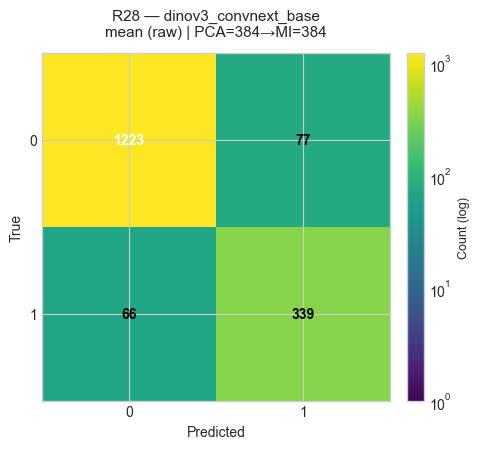

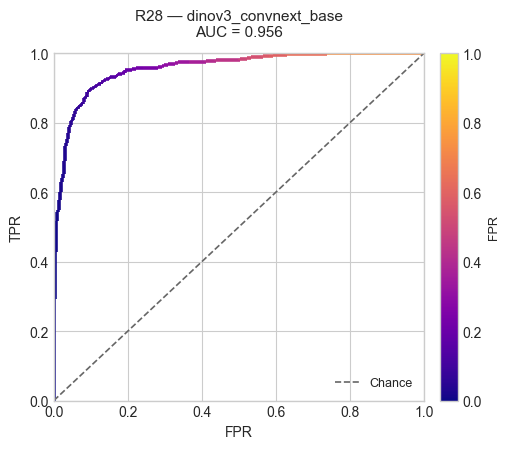


════════════════════════════════════════════════════════════════════════════════
[3/7] R28 — dinov3_vitb16
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6582 | arch=(128,) | lr=0.000301 | w=2.45
  [Bagging] 25 models
  ★ Best: calibrated+noisy_or (val F1=0.8629, thresh=0.498)
  P25: F1=0.8179  AUC=0.9633  BalAcc=0.8858
  CV−Test gap: -0.1596 | Val−Test gap: +0.0451
  Time: 1029s
              precision    recall  f1-score   support

           0      0.948     0.935     0.941      1300
           1      0.800     0.837     0.818       405

    accuracy                          0.911      1705
   macro avg      0.874     0.886     0.880      1705
weighted avg      0.913     0.911     0.912      1705



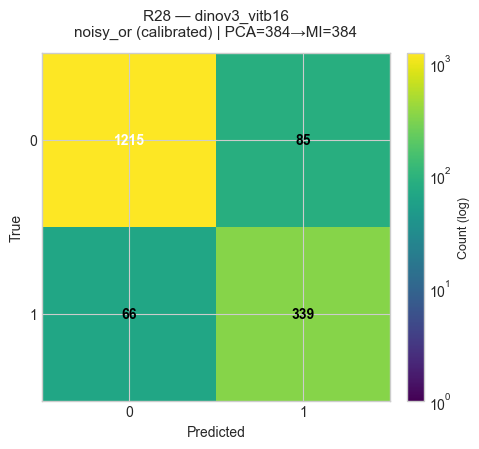

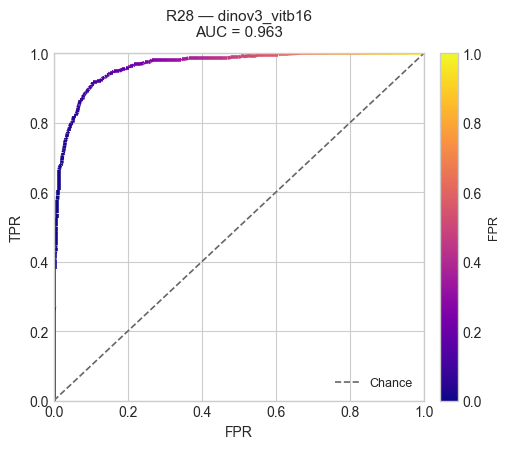


════════════════════════════════════════════════════════════════════════════════
[4/7] R28 — RETFound_dinov2_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.2% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6451 | arch=(512,) | lr=0.000100 | w=2.91
  [Bagging] 25 models
  ★ Best: raw+max (val F1=0.8442, thresh=0.639)
  P25: F1=0.8252  AUC=0.9597  BalAcc=0.8811
  CV−Test gap: -0.1801 | Val−Test gap: +0.0190
  Time: 2723s
              precision    recall  f1-score   support

           0      0.941     0.952     0.947      1300
           1      0.841     0.810     0.825       405

    accuracy                          0.918      1705
   macro avg      0.891     0.881     0.886      1705
weighted avg      0.918     0.918     0.918      1705



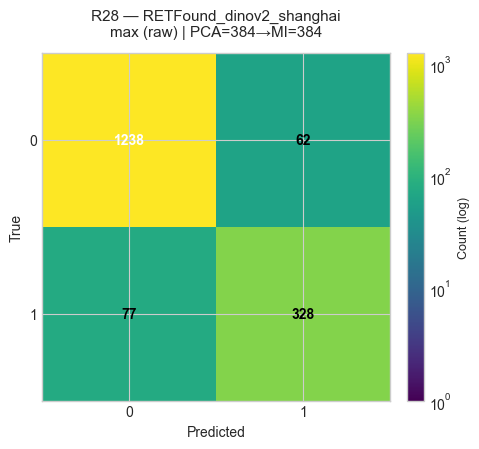

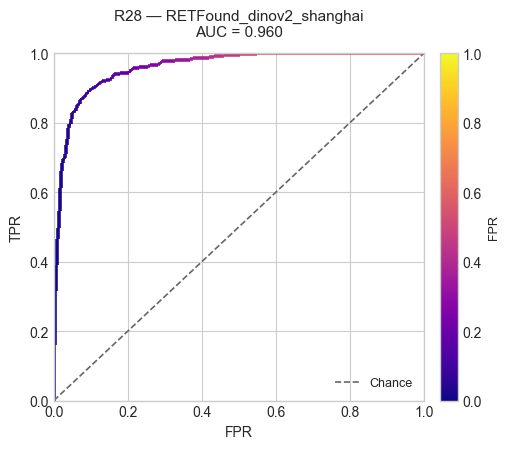


════════════════════════════════════════════════════════════════════════════════
[5/7] R28 — RETFound_mae_natureCFP
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.3% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6146 | arch=(512,) | lr=0.000210 | w=3.37
  [Bagging] 25 models
  ★ Best: calibrated+max (val F1=0.7916, thresh=0.345)
  P25: F1=0.7738  AUC=0.9411  BalAcc=0.8664
  CV−Test gap: -0.1592 | Val−Test gap: +0.0178
  Time: 1296s
              precision    recall  f1-score   support

           0      0.945     0.901     0.922      1300
           1      0.723     0.832     0.774       405

    accuracy                          0.884      1705
   macro avg      0.834     0.866     0.848      1705
weighted avg      0.892     0.884     0.887      1705



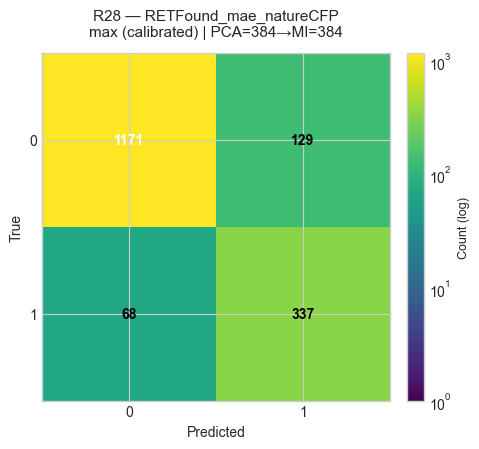

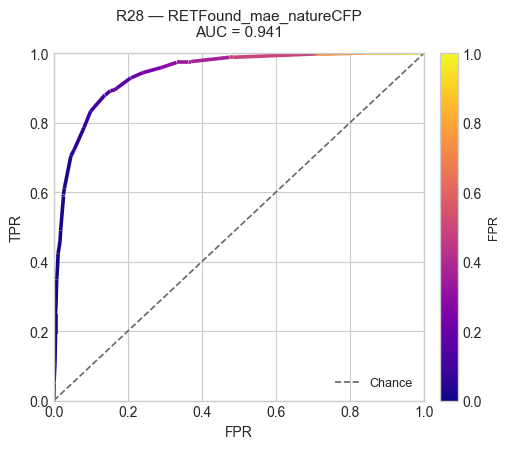


════════════════════════════════════════════════════════════════════════════════
[6/7] R28 — RETFound_mae_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6107 | arch=(256,) | lr=0.002000 | w=1.00
  [Bagging] 25 models
  ★ Best: raw+noisy_or (val F1=0.8627, thresh=0.542)
  P25: F1=0.8205  AUC=0.9612  BalAcc=0.8739
  CV−Test gap: -0.2098 | Val−Test gap: +0.0422
  Time: 1091s
              precision    recall  f1-score   support

           0      0.936     0.958     0.947      1300
           1      0.853     0.790     0.821       405

    accuracy                          0.918      1705
   macro avg      0.895     0.874     0.884      1705
weighted avg      0.916     0.918     0.917      1705



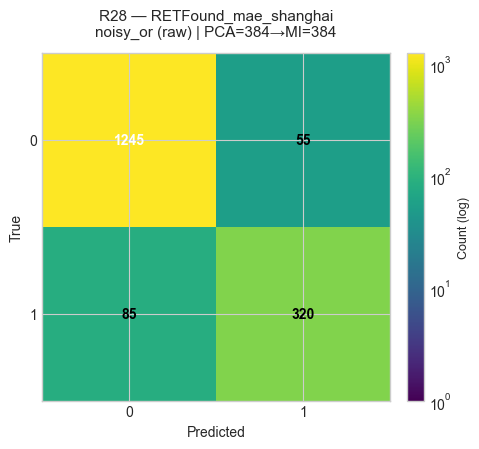

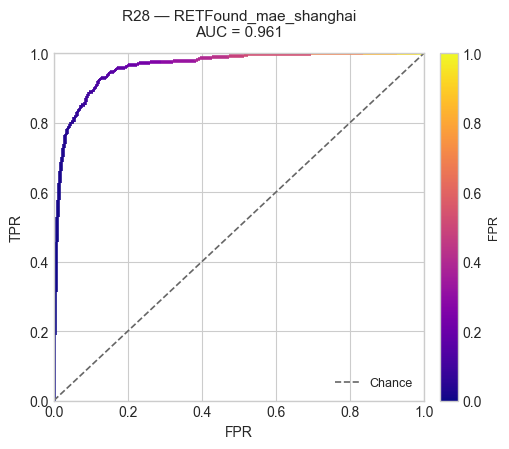


════════════════════════════════════════════════════════════════════════════════
[7/7] R28 — vit_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [BayesSearchCV] 30 iters...
  CV F1=0.6276 | arch=(256,) | lr=0.002000 | w=2.62
  [Bagging] 25 models
  ★ Best: raw+max (val F1=0.8150, thresh=0.570)
  P25: F1=0.7744  AUC=0.9469  BalAcc=0.8523
  CV−Test gap: -0.1468 | Val−Test gap: +0.0406
  Time: 434s
              precision    recall  f1-score   support

           0      0.930     0.929     0.930      1300
           1      0.773     0.775     0.774       405

    accuracy                          0.893      1705
   macro avg      0.852     0.852     0.852      1705
weighted avg      0.893     0.893     0.893      1705



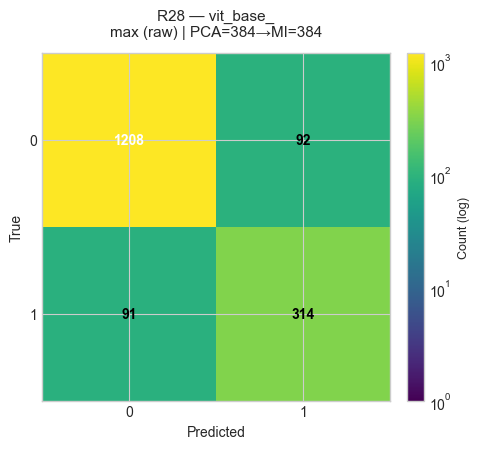

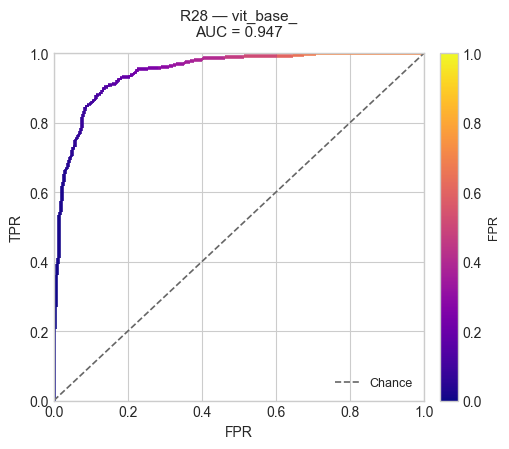


════════════════════════════════════════════════════════════════════════════════
R28 complete! Total: 8117s (135.3 min)
════════════════════════════════════════════════════════════════════════════════

── R28 Per-Encoder Summary (sorted by P25 F1) ──
               embedding    cv_f1   val_f1    f1_P0   f1_P25  f1_P100  auc_P25 best_agg
    dinov3_convnext_base 0.620586 0.856566 0.870732 0.825822 0.606715 0.956253     mean
RETFound_dinov2_shanghai 0.645074 0.844156 0.883375 0.825157 0.566197 0.959683      max
   RETFound_mae_shanghai 0.610733 0.862745 0.890566 0.820513 0.517143 0.961198 noisy_or
           dinov3_vitb16 0.658211 0.862903 0.883832 0.817853 0.632087 0.963338 noisy_or
        convnextv2_base_ 0.668877 0.848861 0.858191 0.809938 0.610667 0.951415      max
               vit_base_ 0.627593 0.814969 0.841448 0.774353 0.555123 0.946860      max
  RETFound_mae_natureCFP 0.614588 0.791587 0.827746 0.773823 0.565064 0.941101      max


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Per-Encoder MLP with FE Split
# ═══════════════════════════════════════════════════════════════════════

R28_DIR = RESULTS_DIR / 'r28_per_encoder'
R28_DIR.mkdir(parents=True, exist_ok=True)

print('═' * 80)
print('R28 — Per-Encoder MLP (PCA-384 + MI) with FE 3-way split')
print('═' * 80)

r28_results = []
t0_b = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R28_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading previous results')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        sc_prev = prev['scenarios']
        r28_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0), 'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'], 'pca_var': prev['pca_var'],
            'dim_total': 0,
            'arch': prev['architecture'], 'alpha': prev['alpha'], 'lr': prev['lr'],
            'pos_weight': prev['pos_weight'], 'cv_f1': prev['best_cv_f1'],
            'val_f1': prev['best_val_f1'], 'best_agg': prev['best_agg'],
            'threshold': prev['threshold'], 'proba_type': prev['proba_type'],
            'f1_P0': sc_prev['P0']['f1'], 'f1_P25': sc_prev['P25']['f1'],
            'f1_P100': sc_prev['P100']['f1'],
            'auc_P0': sc_prev['P0']['auc'], 'auc_P25': sc_prev['P25']['auc'],
            'auc_P100': sc_prev['P100']['auc'],
            'bal_acc_P25': sc_prev['P25']['bal_acc'],
            'prec_P25': sc_prev['P25']['precision'], 'rec_P25': sc_prev['P25']['recall'],
            'n_test_patients': sc_prev['P25']['n_patients'],
            'time_s': 0,
        })
        continue

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R28 — {sname}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ── Load & split ──────────────────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_b_tr = b_train['patient_id'].to_numpy()
    pids_b_va = b_val['patient_id'].to_numpy()
    pids_b_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask_b, mi_scores_b = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept_b = mi_mask_b.sum()
        print(f'  MI: {nc}→{n_kept_b}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept_b = nc

    # ── Metadata ──────────────────────────────────────────────────
    X_tr_meta_b, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta_b, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta_b, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim_b = X_tr_meta_b.shape[1]

    # ── OD masking for BayesSearchCV ──────────────────────────────
    rng_hp_b = np.random.default_rng(RANDOM_SEED)
    od_tr_b, miss_tr_b = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp_b, OD_CORRUPT)
    X_tr_full_b = np.hstack([X_tr_sel, X_tr_meta_b, od_tr_b, miss_tr_b])
    ndim_b = X_tr_full_b.shape[1]
    print(f'  Dims: {n_kept_b} PCA + {meta_dim_b} meta + 2 OD = {ndim_b}')

    # ── Scale ─────────────────────────────────────────────────────
    scaler_b = StandardScaler()
    X_tr_s_b = scaler_b.fit_transform(X_tr_full_b)
    X_tr_s_b = _apply_od_weights(X_tr_s_b, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Pre-compute val/test scenarios
    vt_b = {}
    for sc, pm in [('P0', 0.0), ('P25', OD_TEST_P_MASK), ('P100', 1.0)]:
        rng_vb = np.random.default_rng(RANDOM_SEED + 7000)
        rng_tb = np.random.default_rng(RANDOM_SEED + 9999)
        od_vb, miss_vb = _mask_od(b_val['optic_disc'], pm, rng_vb)
        od_tb, miss_tb = _mask_od(b_test['optic_disc'], pm, rng_tb)
        Xvb = scaler_b.transform(np.hstack([X_va_sel, X_va_meta_b, od_vb, miss_vb]))
        Xtb = scaler_b.transform(np.hstack([X_te_sel, X_te_meta_b, od_tb, miss_tb]))
        vt_b[sc] = (
            _apply_od_weights(Xvb.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT),
            _apply_od_weights(Xtb.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT),
        )

    # ── BayesSearchCV ─────────────────────────────────────────────
    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters...')
    base_b = MLPWrapperForBayesSearch(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    bayes_b = BayesSearchCV(
        estimator=base_b, search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER, cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS, scoring='f1',
        random_state=RANDOM_SEED, verbose=0,
    )
    bayes_b.fit(X_tr_s_b, yb_train)

    bp_b = bayes_b.best_params_
    bcv_f1 = bayes_b.best_score_
    ai = bp_b.get('hidden_layer_sizes', 0)
    barch = ARCHITECTURE_OPTIONS[ai] if isinstance(ai, int) else ai
    balpha = bp_b['alpha']
    blr    = bp_b['learning_rate_init']
    bbs    = bp_b['batch_size']
    bw     = bp_b['pos_class_weight']
    print(f'  CV F1={bcv_f1:.4f} | arch={barch} | lr={blr:.6f} | w={bw:.2f}')

    # ── Bagging ───────────────────────────────────────────────────
    barchs = [barch, make_wider(barch), make_deeper(barch), make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models')

    cal_p = {}
    cal_l = {}
    bvp = {sc: [] for sc in ['P0','P25','P100']}
    btp = {sc: [] for sc in ['P0','P25','P100']}

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_b_tr)
        sss_b = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss_b.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m_b = np.isin(pids_b_tr, list(itr_pids))
        va_m_b = np.isin(pids_b_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(b_train.iloc[np.where(tr_m_b)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler_b.transform(np.hstack([X_tr_sel[tr_m_b], X_tr_meta_b[tr_m_b], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m_b]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(b_train.iloc[np.where(va_m_b)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler_b.transform(np.hstack([X_tr_sel[va_m_b], X_tr_meta_b[va_m_b], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m_b]

        svp = []
        for a_idx, arch_b in enumerate(barchs):
            mlp_b = MLPClassifier(
                hidden_layer_sizes=arch_b, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw_b = make_sample_weights(y_it, bw)
            mlp_b.fit(X_it, y_it, sample_weight=sw_b)

            svp.append(mlp_b.predict_proba(X_iv)[:, 1])

            for sc in ['P0','P25','P100']:
                Xv_sc, Xt_sc = vt_b[sc]
                bvp[sc].append(mlp_b.predict_proba(Xv_sc)[:, 1])
                btp[sc].append(mlp_b.predict_proba(Xt_sc)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp_b = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl_b = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso_b = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso_b.fit(cp_b, cl_b)

    avg_v_b  = {sc: iso_b.predict(np.mean(bvp[sc], axis=0)) for sc in ['P0','P25','P100']}
    avg_t_b  = {sc: iso_b.predict(np.mean(btp[sc], axis=0)) for sc in ['P0','P25','P100']}
    avg_v_bR = {sc: np.mean(bvp[sc], axis=0) for sc in ['P0','P25','P100']}
    avg_t_bR = {sc: np.mean(btp[sc], axis=0) for sc in ['P0','P25','P100']}

    # ── Threshold sweep on FIXED VAL ──────────────────────────────
    plv = aggregate_patient_labels(pids_b_va, yb_val)
    b_agg, b_f1v, b_thr, b_pt = 'mean', 0.0, 0.5, 'calibrated'
    for ptn, vs in [('calibrated', avg_v_b), ('raw', avg_v_bR)]:
        for agg in AGG_METHODS:
            pp = aggregate_patient_proba(pids_b_va, vs['P25'], method=agg)
            com = pp.index.intersection(plv.index)
            t, f = find_optimal_threshold(plv.loc[com].values, pp.loc[com].values,
                                         grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
            if f > b_f1v:
                b_f1v, b_agg, b_thr, b_pt = f, agg, t, ptn

    print(f'  ★ Best: {b_pt}+{b_agg} (val F1={b_f1v:.4f}, thresh={b_thr:.3f})')

    # ── Evaluate on TEST ──────────────────────────────────────────
    plt_b = aggregate_patient_labels(pids_b_te, yb_test)
    b_sc = {}
    for sc in ['P0','P25','P100']:
        tp_b = avg_t_b[sc] if b_pt == 'calibrated' else avg_t_bR[sc]
        pp = aggregate_patient_proba(pids_b_te, tp_b, method=b_agg)
        com = pp.index.intersection(plt_b.index)
        yt = plt_b.loc[com].values
        yp = pp.loc[com].values
        yh = (yp >= b_thr).astype(int)
        b_sc[sc] = {
            'f1': float(f1_score(yt, yh, zero_division=0)),
            'precision': float(precision_score(yt, yh, zero_division=0)),
            'recall': float(recall_score(yt, yh, zero_division=0)),
            'auc': float(roc_auc_score(yt, yp)),
            'bal_acc': float(balanced_accuracy_score(yt, yh)),
            'n_patients': len(com),
        }

    elapsed_b = time.time() - t0
    sb25 = b_sc['P25']
    print(f'  P25: F1={sb25["f1"]:.4f}  AUC={sb25["auc"]:.4f}  BalAcc={sb25["bal_acc"]:.4f}')
    print(f'  CV−Test gap: {bcv_f1 - sb25["f1"]:+.4f} | Val−Test gap: {b_f1v - sb25["f1"]:+.4f}')
    print(f'  Time: {elapsed_b:.0f}s')

    # Save per-embedding
    out_b = R28_DIR / f'{emb_idx:02d}_{sname}'
    out_b.mkdir(parents=True, exist_ok=True)

    tp_main = avg_t_b['P25'] if b_pt == 'calibrated' else avg_t_bR['P25']
    pp_m = aggregate_patient_proba(pids_b_te, tp_main, method=b_agg)
    com_m = pp_m.index.intersection(plt_b.index)
    yt_m = plt_b.loc[com_m].values
    yp_m = pp_m.loc[com_m].values
    yh_m = (yp_m >= b_thr).astype(int)

    cm_b = confusion_matrix(yt_m, yh_m)
    rep_b = classification_report(yt_m, yh_m, digits=3)
    fpr_b, tpr_b, _ = roc_curve(yt_m, yp_m)
    print(rep_b)

    pd.DataFrame(cm_b).to_csv(out_b / 'confusion_matrix.csv', index=False)
    (out_b / 'classification_report.txt').write_text(rep_b, encoding='utf-8')
    pd.DataFrame({'fpr': fpr_b, 'tpr': tpr_b}).to_csv(out_b / 'roc_curve.csv', index=False)
    pd.DataFrame({
        'patient_id': com_m, 'y_true': yt_m, 'y_pred': yh_m, 'y_proba': yp_m,
    }).to_csv(out_b / 'patient_predictions_P25.csv', index=False)

    hp_b = {
        'track': 'R28', 'embedding': sname, 'architecture': str(barch),
        'alpha': float(balpha), 'lr': float(blr), 'batch_size': int(bbs),
        'pos_weight': float(bw), 'best_cv_f1': float(bcv_f1),
        'best_val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt, 'pca_dim': nc, 'mi_selected': int(n_kept_b),
        'pca_var': float(var_exp), 'n_bags': N_BAGS,
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim_b,
        'scenarios': b_sc,
    }
    with open(out_b / 'hyperparameters.json', 'w') as f:
        json.dump(hp_b, f, indent=2)

    plot_confusion_matrix(cm_b, title=f'R28 — {sname}\n{b_agg} ({b_pt}) | PCA={nc}→MI={n_kept_b}',
                          save_path=out_b / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr_b, tpr_b, sb25['auc'], title=f'R28 — {sname}',
                  save_path=out_b / 'roc_curve.png', show=True)

    r28_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept_b),
        'pca_var': float(var_exp), 'dim_total': ndim_b,
        'arch': str(barch), 'alpha': float(balpha), 'lr': float(blr),
        'pos_weight': float(bw), 'cv_f1': float(bcv_f1),
        'val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt,
        'f1_P0': b_sc['P0']['f1'], 'f1_P25': b_sc['P25']['f1'], 'f1_P100': b_sc['P100']['f1'],
        'auc_P0': b_sc['P0']['auc'], 'auc_P25': b_sc['P25']['auc'], 'auc_P100': b_sc['P100']['auc'],
        'bal_acc_P25': b_sc['P25']['bal_acc'],
        'prec_P25': b_sc['P25']['precision'], 'rec_P25': b_sc['P25']['recall'],
        'n_test_patients': b_sc['P25']['n_patients'],
        'time_s': float(elapsed_b),
    })

total_b = time.time() - t0_b
print(f'\n{"═"*80}')
print(f'R28 complete! Total: {total_b:.0f}s ({total_b/60:.1f} min)')
print(f'{"═"*80}')

# Save summary
r28_df = pd.DataFrame(r28_results).sort_values('f1_P25', ascending=False)
r28_df.to_csv(R28_DIR / 'r28_summary.csv', index=False)

print('\n── R28 Per-Encoder Summary (sorted by P25 F1) ──')
show_cols = ['embedding', 'cv_f1', 'val_f1', 'f1_P0', 'f1_P25', 'f1_P100', 'auc_P25', 'best_agg']
print(r28_df[[c for c in show_cols if c in r28_df.columns]].to_string(index=False))

---
## Training & Validation Loss Diagnostics

Re-trains a **single representative MLP** per encoder using the best hyperparameters found
during BayesSearchCV. Captures `loss_curve_` (training loss per epoch) and `validation_scores_`
(internal early-stopping metric) from sklearn's MLPClassifier.

This is NOT the full 25-bag ensemble — just a quick single-model diagnostic to verify
convergence and check for under/overfitting patterns.

Found 7 embedding files, 5796 train patients
[1/7] convnextv2_base_ — arch=(128,), α=1.0000, lr=0.000100, w=4.07
  Epochs: 64/400 (early stopped)
  Final train loss: 0.3208 | Best val score: 0.8446
[2/7] dinov3_convnext_base — arch=(128,), α=1.0000, lr=0.000358, w=2.46
  Epochs: 48/400 (early stopped)
  Final train loss: 0.3394 | Best val score: 0.8339
[3/7] dinov3_vitb16 — arch=(128,), α=1.0000, lr=0.000301, w=2.45
  Epochs: 55/400 (early stopped)
  Final train loss: 0.1747 | Best val score: 0.8208
[4/7] RETFound_dinov2_shanghai — arch=(512,), α=1.0000, lr=0.000100, w=2.91
  Epochs: 67/400 (early stopped)
  Final train loss: 0.3174 | Best val score: 0.8251
[5/7] RETFound_mae_natureCFP — arch=(512,), α=0.0010, lr=0.000210, w=3.37
  Epochs: 40/400 (early stopped)
  Final train loss: 0.0069 | Best val score: 0.7954
[6/7] RETFound_mae_shanghai — arch=(256,), α=0.0014, lr=0.002000, w=1.00
  Epochs: 56/400 (early stopped)
  Final train loss: 0.0080 | Best val score: 0.8788
[7/7] vit_base_ —

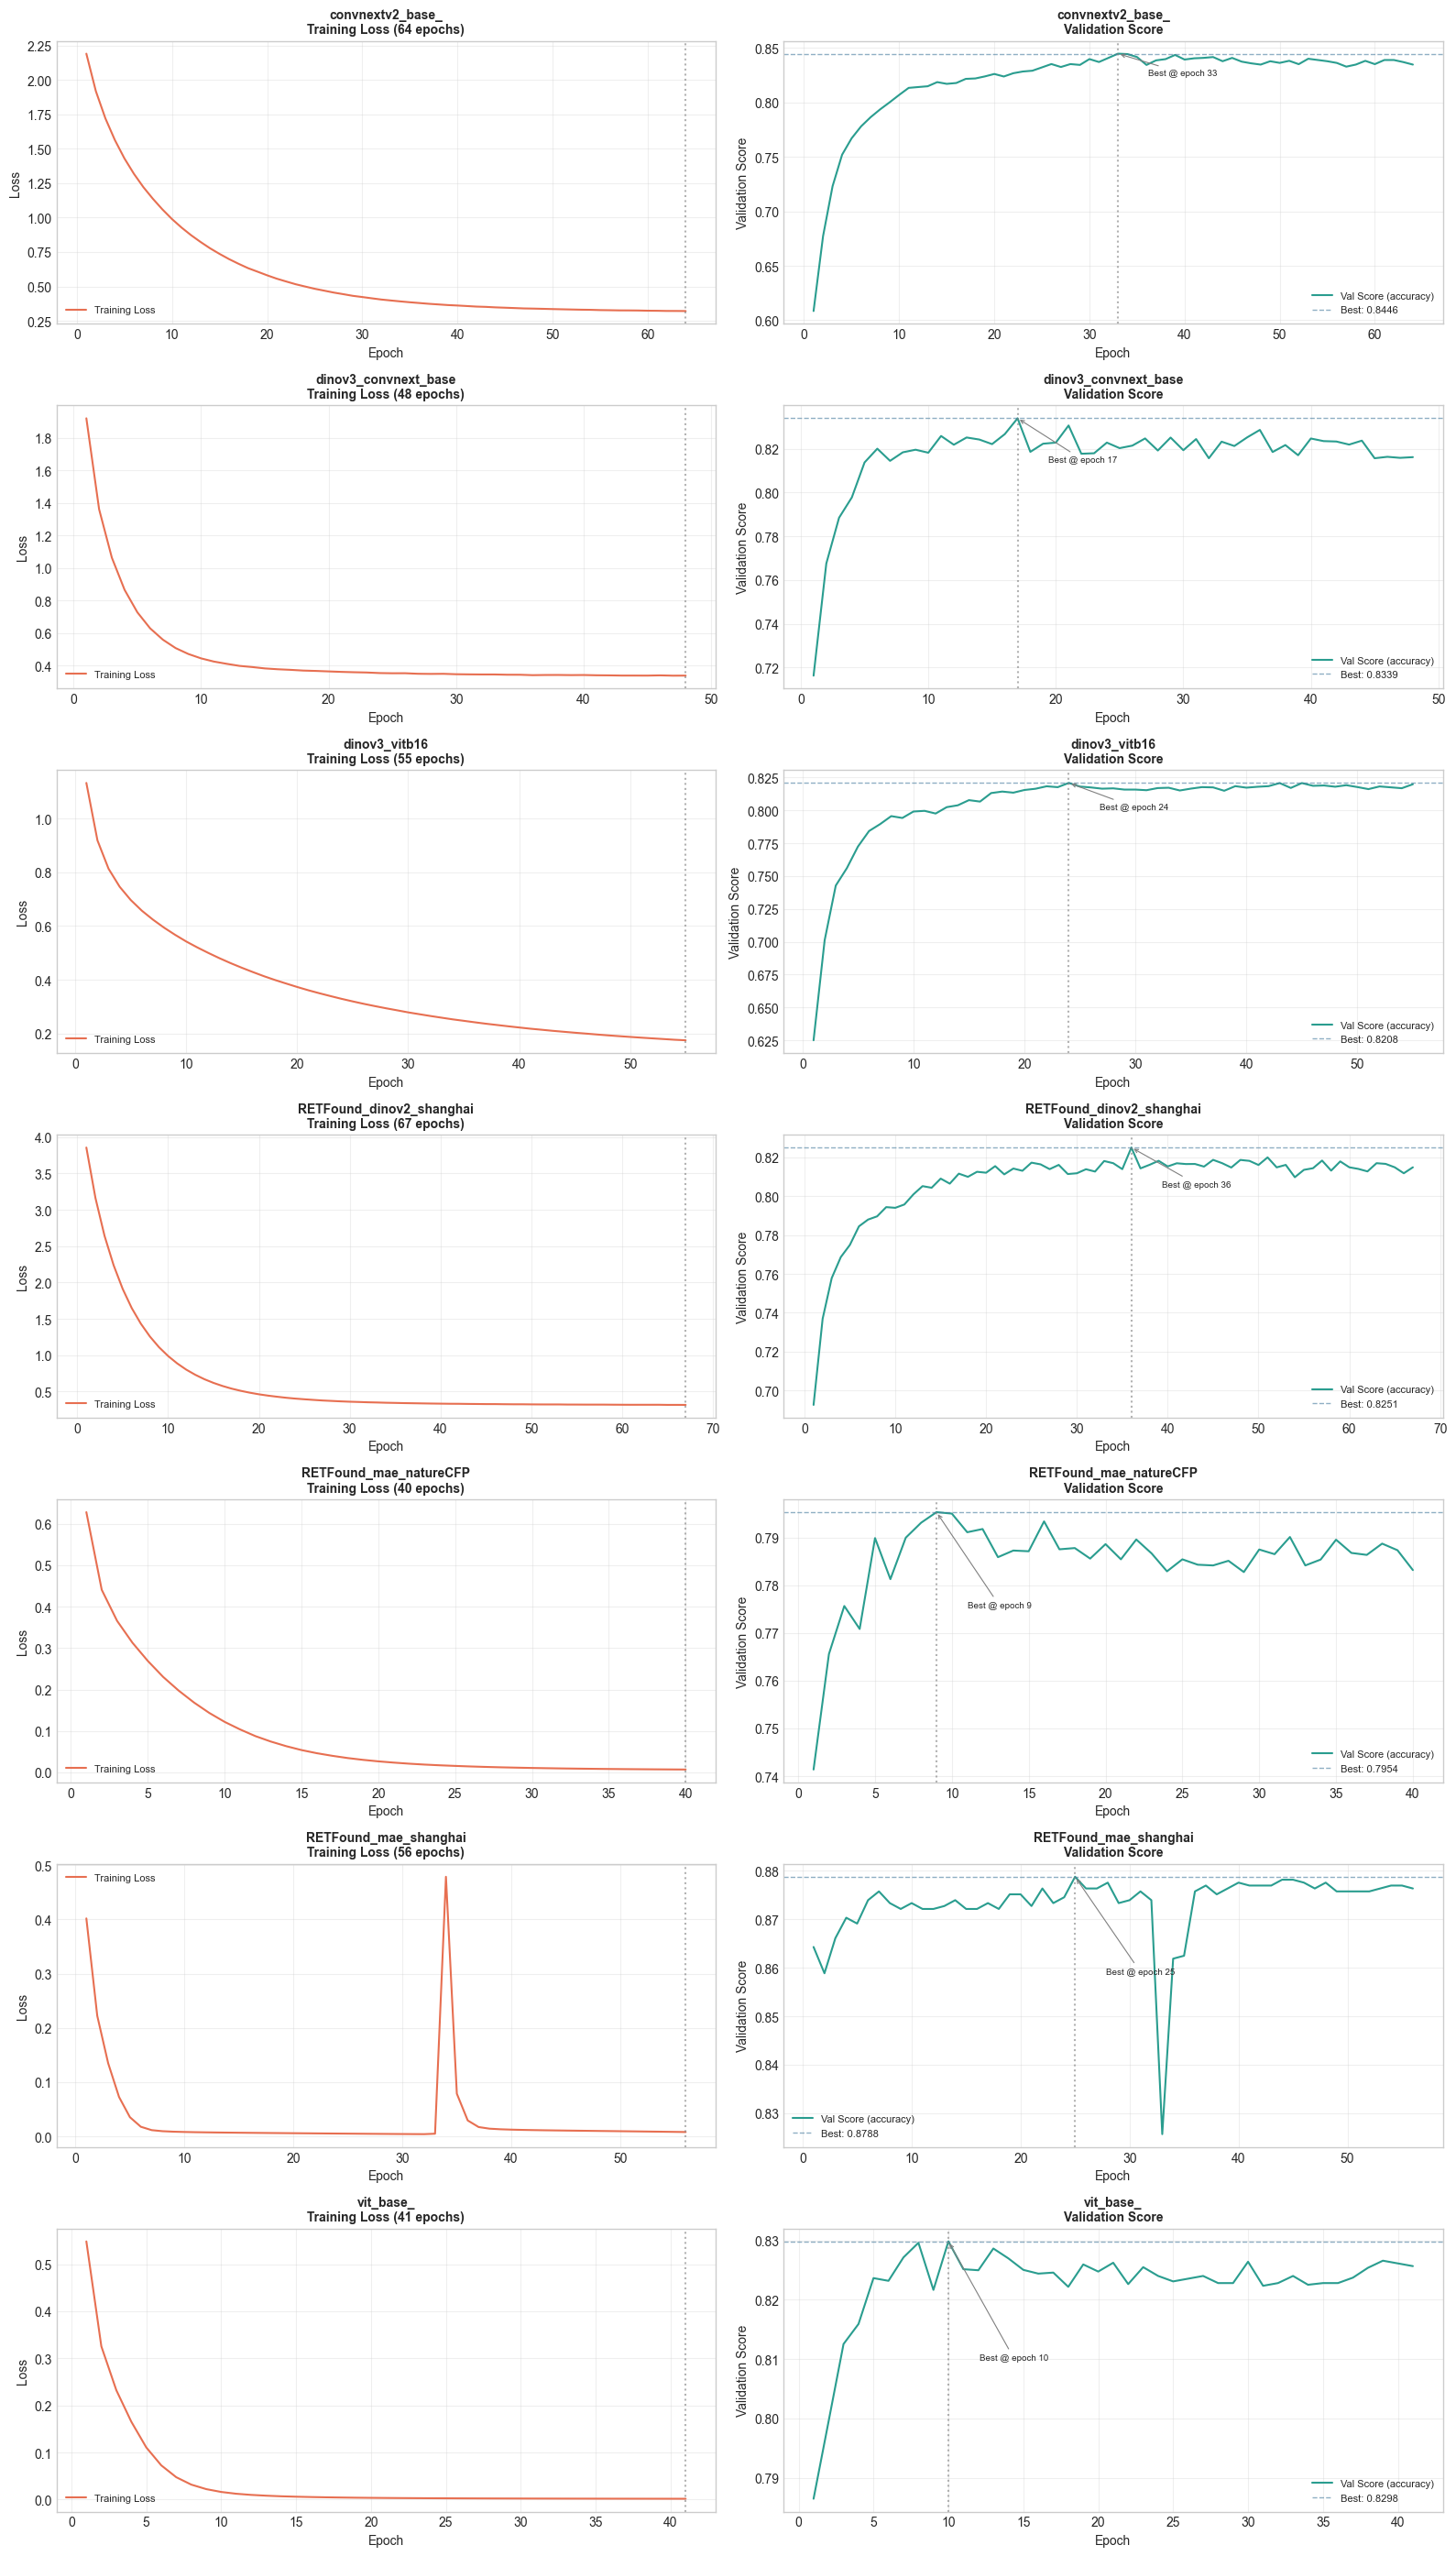


Loss curves saved to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r28_fe_experiment\loss_curves
────────────────────────────────────────────────────────────
What to look for:
  ✓ Training loss should decrease smoothly (no spikes)
  ✓ Val score should plateau, not crash (no overfitting)
  ✓ Early stopping should trigger (not hitting max_iter)
  ✗ If val score drops while train loss drops → overfitting
  ✗ If train loss is still falling at max_iter → underfitting


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Cell — Training & Validation Loss Curves (single-model diagnostic)
# Self-contained: can be run without executing prior cells.
# Loads best HPs from saved checkpoints, retrains a SINGLE MLP per
# encoder (not the full 25-bag ensemble) to capture loss curves.
# ═══════════════════════════════════════════════════════════════════════

# ─── Imports ──────────────────────────────────────────────────────
import os, sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')

sys.path.insert(0, str(Path.cwd() / 'src'))
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

# ─── Config (mirrors notebook cells 2-3) ─────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r28_fe_experiment'
R28_DIR      = RESULTS_DIR / 'r28_per_encoder'

DATASET_NAME   = 'brset'
TASK           = 'increased_cup_disc'
RANDOM_SEED    = 42
PCA_COMPONENTS = 384
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128
MI_SELECTION         = True
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30
OD_P_MASK_BASE = 0.50
OD_CORRUPT     = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50

METADATA_COLS = {
    'age': 'numeric', 'sex': 'passthrough', 'diabetes': 'binary_yn',
    'exam_eye': 'binary', 'camera': 'camera',
}

# ─── Load splits + labels ────────────────────────────────────────
splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)
train_pids = set(splits[splits['split'] == 'train']['patient_id'])

labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))
print(f'Found {len(embedding_files)} embedding files, {len(train_pids)} train patients')

# ─── Compact helpers (same logic as cell 5) ──────────────────────
def short_name(p):
    s = Path(p).stem
    for x in ['Embeddings_brset_', 'Embeddings_']: s = s.replace(x, '')
    return s

def make_sample_weights(y, pw=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pw), 1.0).astype(np.float32)
    m = w.mean()
    return w / m if m > 0 else w

def encode_metadata(df, mcols, fit_stats=None):
    if fit_stats is None: fit_stats = {}
    parts = []
    for col, dt in mcols.items():
        if col not in df.columns: continue
        v = df[col].copy()
        if dt == 'numeric':
            v = pd.to_numeric(v, errors='coerce')
            if 'median_' + col not in fit_stats: fit_stats['median_' + col] = float(v.median())
            v = v.fillna(fit_stats['median_' + col])
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dt == 'binary':
            v = pd.to_numeric(v, errors='coerce').fillna(1); v = (v - 1).clip(0, 1)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dt == 'passthrough':
            v = pd.to_numeric(v, errors='coerce').fillna(0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dt == 'binary_yn':
            v = v.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dt == 'camera':
            v = v.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            parts.append(v.to_numpy(dtype=np.float32).reshape(-1, 1))
    return (np.hstack(parts), fit_stats) if parts else (np.zeros((len(df), 0), dtype=np.float32), fit_stats)

def _bin_od(s):
    return (pd.to_numeric(s, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_s, pm, rng, pc=0.0):
    od = _bin_od(od_s)
    if pm >= 1.0:    miss = np.ones(len(od), dtype=bool)
    elif pm > 0:     miss = rng.random(len(od)) < pm
    else:            miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy(); od_m[miss] = 0.0
    if pc > 0:
        corrupt = (~miss) & (rng.random(len(od)) < pc)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X, ow, mw):
    if X.shape[1] < 2: return X
    if ow != 1.0: X[:, -2] *= ow
    if mw != 1.0: X[:, -1] *= mw
    return X

def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128, random_state=42):
    mi = mutual_info_classif(X_train, y_train, discrete_features=False,
                             n_neighbors=5, random_state=random_state)
    thr = np.percentile(mi, percentile_thresh * 100)
    mask = mi >= thr
    if mask.sum() < min_components:
        top_k = np.argsort(mi)[-min_components:]
        mask = np.zeros(len(mi), dtype=bool); mask[top_k] = True
    return X_train[:, mask], [X[:, mask] for X in X_others], mask, mi

# ═══════════════════════════════════════════════════════════════════
# Main: retrain single MLP per encoder & capture loss curves
# ═══════════════════════════════════════════════════════════════════
LOSS_DIR = RESULTS_DIR / 'loss_curves'
LOSS_DIR.mkdir(parents=True, exist_ok=True)

n_enc = len(embedding_files)
fig_all, axes_all = plt.subplots(n_enc, 2, figsize=(16, 4 * n_enc))
if n_enc == 1:
    axes_all = axes_all.reshape(1, -1)

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Load best hyperparameters from checkpoint ──────────────────
    chk_dir = R28_DIR / f'{emb_idx:02d}_{sname}'
    hp_path = chk_dir / 'hyperparameters.json'
    if not hp_path.exists():
        print(f'[{emb_idx+1}] {sname} — no checkpoint, skipping')
        continue
    with open(hp_path) as f:
        hp = json.load(f)

    arch  = eval(hp['architecture'])
    alpha = hp['alpha']
    lr    = hp['lr']
    bs    = hp['batch_size']
    pw    = hp['pos_weight']

    print(f'[{emb_idx+1}/{n_enc}] {sname} — arch={arch}, α={alpha:.4f}, lr={lr:.6f}, w={pw:.2f}')

    # ── Load & prepare data ────────────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    yb_train = b_train[TASK].to_numpy(dtype=int)

    # PCA
    emb_dim_raw = X_tr_emb.shape[1]
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)

    # MI selection
    if MI_SELECTION:
        X_tr_sel, _, _, _ = mi_select_features(
            X_tr_pca, yb_train, [],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
    else:
        X_tr_sel = X_tr_pca

    # Metadata + OD masking
    X_tr_meta, _ = encode_metadata(b_train, METADATA_COLS)
    rng_od = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_od, OD_CORRUPT)
    X_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_full)
    X_s = _apply_od_weights(X_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ── Train single MLP with best HPs ─────────────────────────────
    mlp = MLPClassifier(
        hidden_layer_sizes=arch, alpha=alpha,
        learning_rate='adaptive', learning_rate_init=lr,
        batch_size=bs, max_iter=MLP_MAX_ITER,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=MLP_PATIENCE, random_state=RANDOM_SEED,
    )
    sw = make_sample_weights(yb_train, pw)
    mlp.fit(X_s, yb_train, sample_weight=sw)

    train_loss = mlp.loss_curve_
    val_scores = mlp.validation_scores_ if hasattr(mlp, 'validation_scores_') else None
    n_epochs = len(train_loss)
    stopped_early = n_epochs < MLP_MAX_ITER

    print(f'  Epochs: {n_epochs}/{MLP_MAX_ITER} {"(early stopped)" if stopped_early else "(max iter)"}')
    print(f'  Final train loss: {train_loss[-1]:.4f} | Best val score: {mlp.best_validation_score_:.4f}')

    # ── Plot ───────────────────────────────────────────────────────
    ax1 = axes_all[emb_idx, 0]
    ax2 = axes_all[emb_idx, 1]
    epochs = range(1, n_epochs + 1)

    # Training loss
    ax1.plot(epochs, train_loss, color='#E76F51', linewidth=1.5, label='Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{sname}\nTraining Loss ({n_epochs} epochs)', fontsize=10, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    if stopped_early:
        ax1.axvline(x=n_epochs, color='gray', linestyle=':', alpha=0.6, label='Early stop')

    # Validation score
    if val_scores is not None:
        ax2.plot(range(1, len(val_scores)+1), val_scores, color='#2A9D8F', linewidth=1.5,
                 label='Val Score (accuracy)')
        ax2.axhline(y=mlp.best_validation_score_, color='#457B9D', linestyle='--',
                     alpha=0.6, linewidth=1, label=f'Best: {mlp.best_validation_score_:.4f}')
        if stopped_early:
            best_epoch = val_scores.index(mlp.best_validation_score_) + 1
            ax2.axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
            ax2.annotate(f'Best @ epoch {best_epoch}', xy=(best_epoch, mlp.best_validation_score_),
                         xytext=(best_epoch + n_epochs*0.05, mlp.best_validation_score_ - 0.02),
                         fontsize=7, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    else:
        ax2.text(0.5, 0.5, 'No validation scores\n(early_stopping=False)',
                 transform=ax2.transAxes, ha='center', va='center', fontsize=10, color='gray')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Score')
    ax2.set_title(f'{sname}\nValidation Score', fontsize=10, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # Save per-encoder loss data
    loss_data = pd.DataFrame({'epoch': list(epochs), 'train_loss': train_loss})
    if val_scores is not None:
        loss_data['val_score'] = val_scores + [np.nan] * (n_epochs - len(val_scores))
    loss_data.to_csv(LOSS_DIR / f'{emb_idx:02d}_{sname}_loss.csv', index=False)

plt.tight_layout()
fig_all.savefig(LOSS_DIR / 'all_encoders_loss_curves.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'\nLoss curves saved to: {LOSS_DIR}')
print('─' * 60)
print('What to look for:')
print('  ✓ Training loss should decrease smoothly (no spikes)')
print('  ✓ Val score should plateau, not crash (no overfitting)')
print('  ✓ Early stopping should trigger (not hitting max_iter)')
print('  ✗ If val score drops while train loss drops → overfitting')
print('  ✗ If train loss is still falling at max_iter → underfitting')

---
## R28 vs R27 Comparison

Loaded R27 baseline: 7 embeddings

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
R28 (Per-Encoder MLP, FE Split) vs R27 Baseline
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
model                embedding    cv_f1   val_f1    f1_P0   f1_P25  f1_P100  auc_P25
  R28     dinov3_convnext_base 0.620586 0.856566 0.870732 0.825822 0.606715 0.956253
  R28 RETFound_dinov2_shanghai 0.645074 0.844156 0.883375 0.825157 0.566197 0.959683
  R28    RETFound_mae_shanghai 0.610733 0.862745 0.890566 0.820513 0.517143 0.961198
  R28            dinov3_vitb16 0.658211 0.862903 0.883832 0.817853 0.632087 0.963338
  R28         convnextv2_base_ 0.668877 0.848861 0.858191 0.809938 0.610667 0.951415
  R28                vit_base_ 0.627593 0.814969 0.841448 0.774353 0.555123 0.946860
  R28   RETFound_mae_natureCFP 0.614588 0.791587 0.827746 0.773823 0.565064 0.941101
  R27     dinov

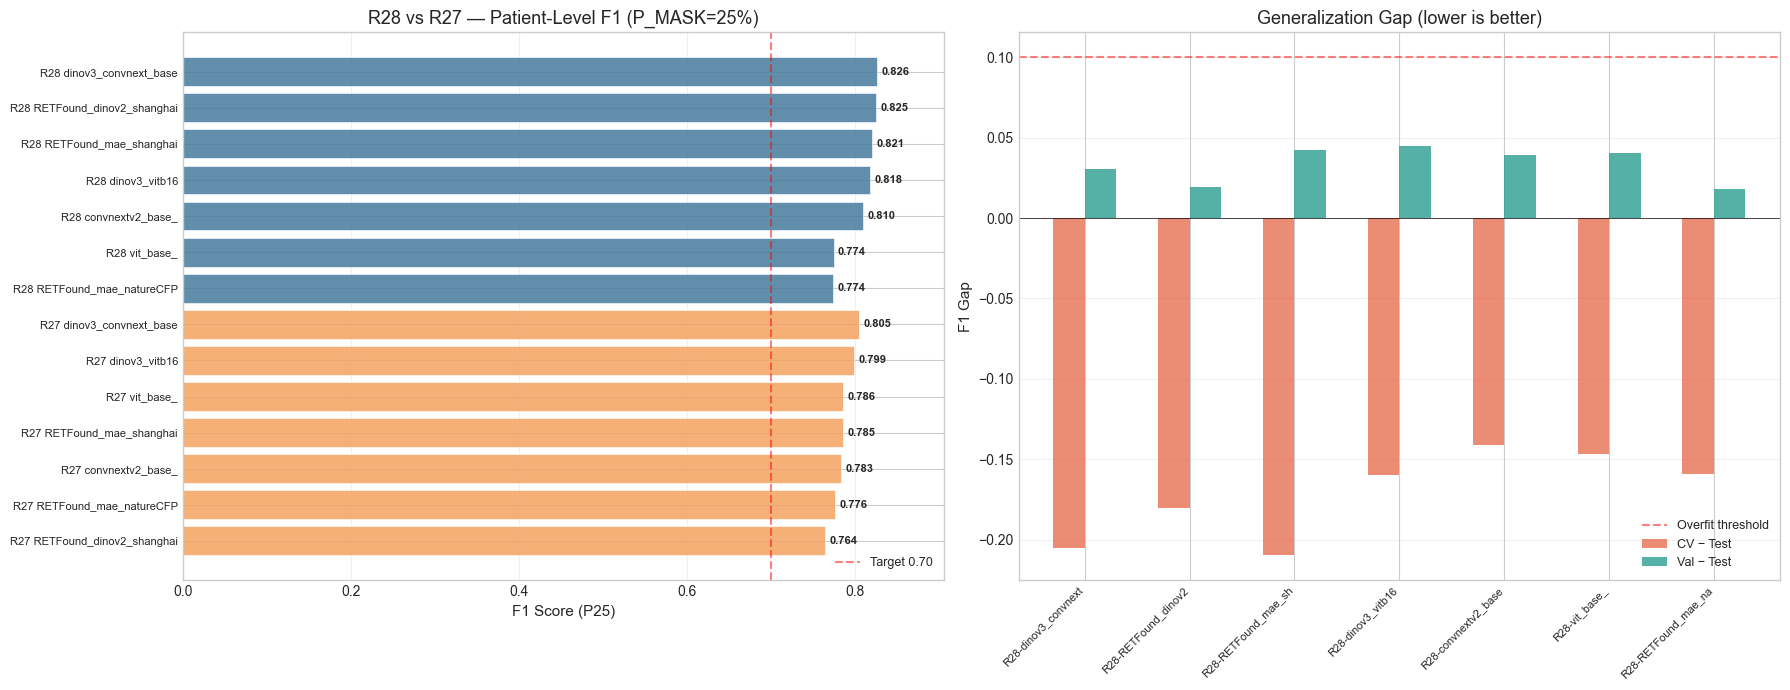


── Summary Statistics ──
R28 best:  F1=0.8258  AUC=0.9633  (dinov3_convnext_base)
R28 mean:  F1=0.8068  AUC=0.9543
R27 best:  F1=0.8048  AUC=0.9573  (dinov3_convnext_base)
R27 mean:  F1=0.7853  AUC=0.9516

── Per-Embedding Δ (R28 minus R27) ──
  dinov3_convnext_base           Δ F1 = +0.0210
  RETFound_dinov2_shanghai       Δ F1 = +0.0611
  RETFound_mae_shanghai          Δ F1 = +0.0351
  dinov3_vitb16                  Δ F1 = +0.0194
  convnextv2_base_               Δ F1 = +0.0268
  vit_base_                      Δ F1 = -0.0112
  RETFound_mae_natureCFP         Δ F1 = -0.0021

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r28_fe_experiment


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — R28 vs R27 Comparison & Visualization
# ═══════════════════════════════════════════════════════════════════════

# ─── Load R27 baseline (if available) ─────────────────────────────
has_r27 = R27_SUMMARY.exists()
if has_r27:
    r27_df = pd.read_csv(R27_SUMMARY)
    print(f'Loaded R27 baseline: {len(r27_df)} embeddings')
else:
    r27_df = pd.DataFrame()
    print('R27 baseline not found — comparison will be R28-only')

# ─── Build comparison table ───────────────────────────────────────
rows = []

# R28 per-encoder results
for _, r in r28_df.iterrows():
    rows.append({
        'model': 'R28',
        'embedding': r['embedding'],
        'f1_P25': r['f1_P25'], 'auc_P25': r['auc_P25'],
        'bal_acc_P25': r['bal_acc_P25'],
        'prec_P25': r['prec_P25'], 'rec_P25': r['rec_P25'],
        'f1_P0': r['f1_P0'], 'f1_P100': r['f1_P100'],
        'cv_f1': r['cv_f1'], 'val_f1': r['val_f1'],
    })

# R27 baseline (per embedding)
if has_r27:
    for _, r in r27_df.iterrows():
        rows.append({
            'model': 'R27',
            'embedding': r['embedding'],
            'f1_P25': r.get('f1_eye_P25', r.get('f1_pat_P25', 0)),
            'auc_P25': r.get('auc_eye_P25', r.get('auc_pat_P25', 0)),
            'bal_acc_P25': 0,  # may not exist in R27
            'prec_P25': 0,
            'rec_P25': 0,
            'f1_P0': r.get('f1_eye_P0', r.get('f1_pat_P0', 0)),
            'f1_P100': r.get('f1_eye_P100', r.get('f1_pat_P100', 0)),
            'cv_f1': r.get('cv_f1', 0),
            'val_f1': r.get('val_eye_f1', 0),
        })

comp_df = pd.DataFrame(rows)
comp_df.to_csv(RESULTS_DIR / 'r28_comparison.csv', index=False)

print('\n' + '═' * 110)
print('R28 (Per-Encoder MLP, FE Split) vs R27 Baseline')
print('═' * 110)
print(comp_df[['model','embedding','cv_f1','val_f1','f1_P0','f1_P25','f1_P100','auc_P25']].to_string(index=False))

# ─── Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: F1 P25 bar chart
ax = axes[0]
models = [f'R28 {e}' for e in r28_df['embedding']]
f1s = r28_df['f1_P25'].tolist()
colors = ['#457B9D'] * len(r28_df)

if has_r27:
    for _, r in r27_df.iterrows():
        models.append(f'R27 {r["embedding"]}')
        f1s.append(r.get('f1_eye_P25', r.get('f1_pat_P25', 0)))
        colors.append('#F4A261')

y_pos = np.arange(len(models))
bars = ax.barh(y_pos, f1s, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel('F1 Score (P25)', fontsize=11)
ax.set_title('R28 vs R27 — Patient-Level F1 (P_MASK=25%)', fontsize=13)
ax.axvline(x=0.70, color='red', linestyle='--', alpha=0.5, label='Target 0.70')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, max(f1s) + 0.08)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Right: Overfitting gap (CV F1 − Test F1)
ax2 = axes[1]
gap_models = []
gap_cv = []
gap_val = []

for _, r in r28_df.iterrows():
    gap_models.append(f'R28-{r["embedding"][:15]}')
    gap_cv.append(r['cv_f1'] - r['f1_P25'])
    gap_val.append(r['val_f1'] - r['f1_P25'])

x = np.arange(len(gap_models))
ax2.bar(x - 0.15, gap_cv, 0.3, label='CV − Test', color='#E76F51', alpha=0.8)
ax2.bar(x + 0.15, gap_val, 0.3, label='Val − Test', color='#2A9D8F', alpha=0.8)
ax2.axhline(y=0.10, color='red', linestyle='--', alpha=0.5, label='Overfit threshold')
ax2.axhline(y=0.0, color='black', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(gap_models, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('F1 Gap', fontsize=11)
ax2.set_title('Generalization Gap (lower is better)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'r28_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── Summary statistics ───────────────────────────────────────────
print('\n── Summary Statistics ──')
print(f'R28 best:  F1={r28_df["f1_P25"].max():.4f}  AUC={r28_df["auc_P25"].max():.4f}  ({r28_df.iloc[0]["embedding"]})')
print(f'R28 mean:  F1={r28_df["f1_P25"].mean():.4f}  AUC={r28_df["auc_P25"].mean():.4f}')
if has_r27:
    r27_f1_col = 'f1_eye_P25' if 'f1_eye_P25' in r27_df.columns else 'f1_pat_P25'
    r27_auc_col = 'auc_eye_P25' if 'auc_eye_P25' in r27_df.columns else 'auc_pat_P25'
    print(f'R27 best:  F1={r27_df[r27_f1_col].max():.4f}  AUC={r27_df[r27_auc_col].max():.4f}  ({r27_df.loc[r27_df[r27_f1_col].idxmax(), "embedding"]})')
    print(f'R27 mean:  F1={r27_df[r27_f1_col].mean():.4f}  AUC={r27_df[r27_auc_col].mean():.4f}')
    # Per-embedding delta
    print('\n── Per-Embedding Δ (R28 minus R27) ──')
    for _, rb in r28_df.iterrows():
        emb = rb['embedding']
        m27 = r27_df[r27_df['embedding'] == emb]
        if not m27.empty:
            d = rb['f1_P25'] - m27[r27_f1_col].values[0]
            print(f'  {emb:<30} Δ F1 = {d:+.4f}')

print(f'\nSaved: {RESULTS_DIR}')

---
## Interpretation Notes

**What to look for:**

1. **R28 vs R27:** If R28 wins → the cleaner 3-way split and honest val set improve
   threshold calibration, even with the same per-encoder pipeline.
2. **CV − Test gap:** If R28 gaps are smaller than R27's → the FE split reduces overfitting.
3. **P0 − P100 spread:** How much does `optic_disc` availability matter across encoders?
4. **Encoder ranking:** Does the rank ordering of encoders change between R27 and R28 splits?

**Important caveats:**
- R27 and R28 use **different patient splits**, so F1 comparisons are on **different test sets**.
  Only 336 of 1,705 test patients overlap. Rank ordering of encoders is more meaningful than
  absolute F1 differences.
- R27 remains the clinical deployment candidate. This notebook is an **experimental comparison**
  to guide future architecture decisions.

## § 13 — Validation Suite

Five independent tests that assess R28 model quality **without retraining**.
All plots and tables are generated from the saved `patient_predictions_P25.csv` files.

| # | Test | Purpose |
|---|------|---------|
| 1 | **Bootstrap 95 % CIs** | Quantify uncertainty around F1 / AUC point estimates |
| 2 | **Calibration (Reliability) Diagrams** | Are predicted probabilities trustworthy? |
| 3 | **Subgroup Fairness** | F1 by age, sex, diabetes status, camera |
| 4 | **Inter-Encoder Agreement** | Pairwise Cohen's κ — how much do models agree? |
| 5 | **Prediction Error Analysis** | Which patients does *everyone* get wrong? |

✓ Loaded 7 encoders, 1705 test patients each

════════════════════════════════════════════════════════════════════════
  TEST 1 — Bootstrap 95 % Confidence Intervals  (n = 1,000 resamples)
════════════════════════════════════════════════════════════════════════
  CNv2          F1 0.810 [0.778–0.840]   AUC 0.951 [0.939–0.962]   Prec 0.815 [0.779–0.854]   Rec 0.805 [0.764–0.842]
  DINOv3-CN     F1 0.826 [0.799–0.853]   AUC 0.957 [0.945–0.967]   Prec 0.816 [0.780–0.852]   Rec 0.837 [0.797–0.873]
  DINOv3-ViT    F1 0.818 [0.789–0.845]   AUC 0.964 [0.954–0.972]   Prec 0.799 [0.760–0.838]   Rec 0.838 [0.802–0.871]
  RF-DINOv2     F1 0.826 [0.796–0.853]   AUC 0.960 [0.950–0.969]   Prec 0.842 [0.803–0.878]   Rec 0.810 [0.772–0.847]
  RF-MAE-CFP    F1 0.773 [0.743–0.802]   AUC 0.941 [0.929–0.952]   Prec 0.723 [0.682–0.763]   Rec 0.832 [0.796–0.868]
  RF-MAE-SH     F1 0.820 [0.788–0.850]   AUC 0.961 [0.951–0.970]   Prec 0.853 [0.815–0.888]   Rec 0.790 [0.747–0.830]
  ViT-B         F1 0.774 [0.74

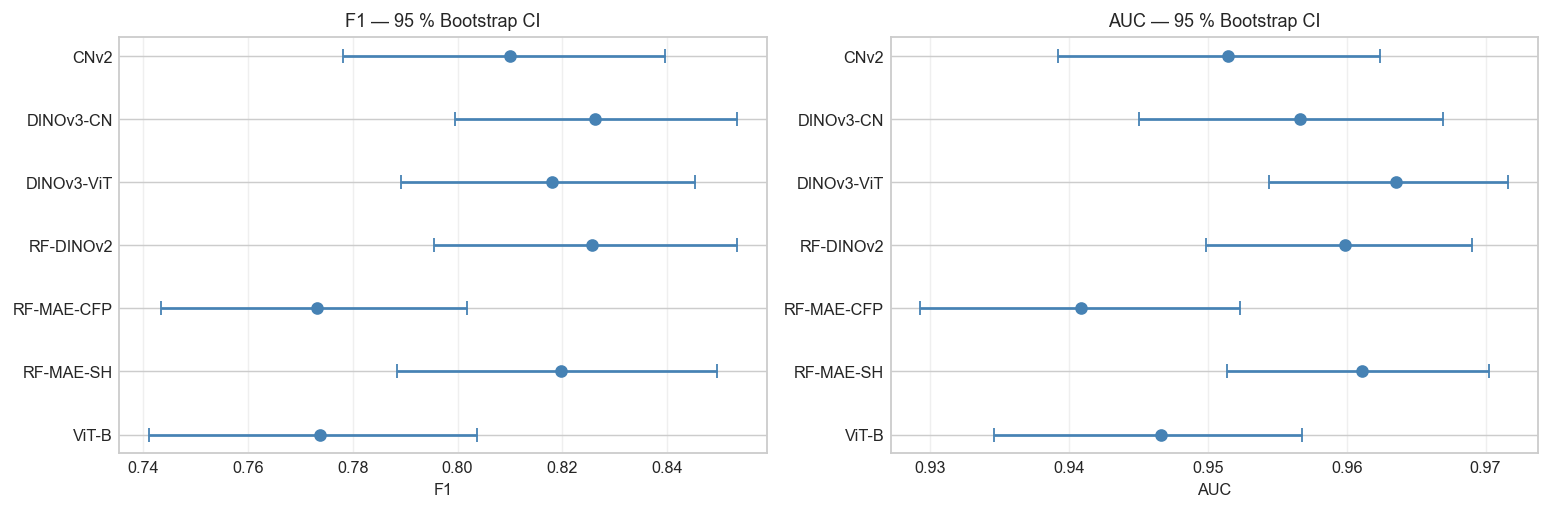


  → Saved to validation_suite/test1_bootstrap_ci.csv + .png

════════════════════════════════════════════════════════════════════════
  TEST 2 — Calibration (Reliability) Diagrams
════════════════════════════════════════════════════════════════════════


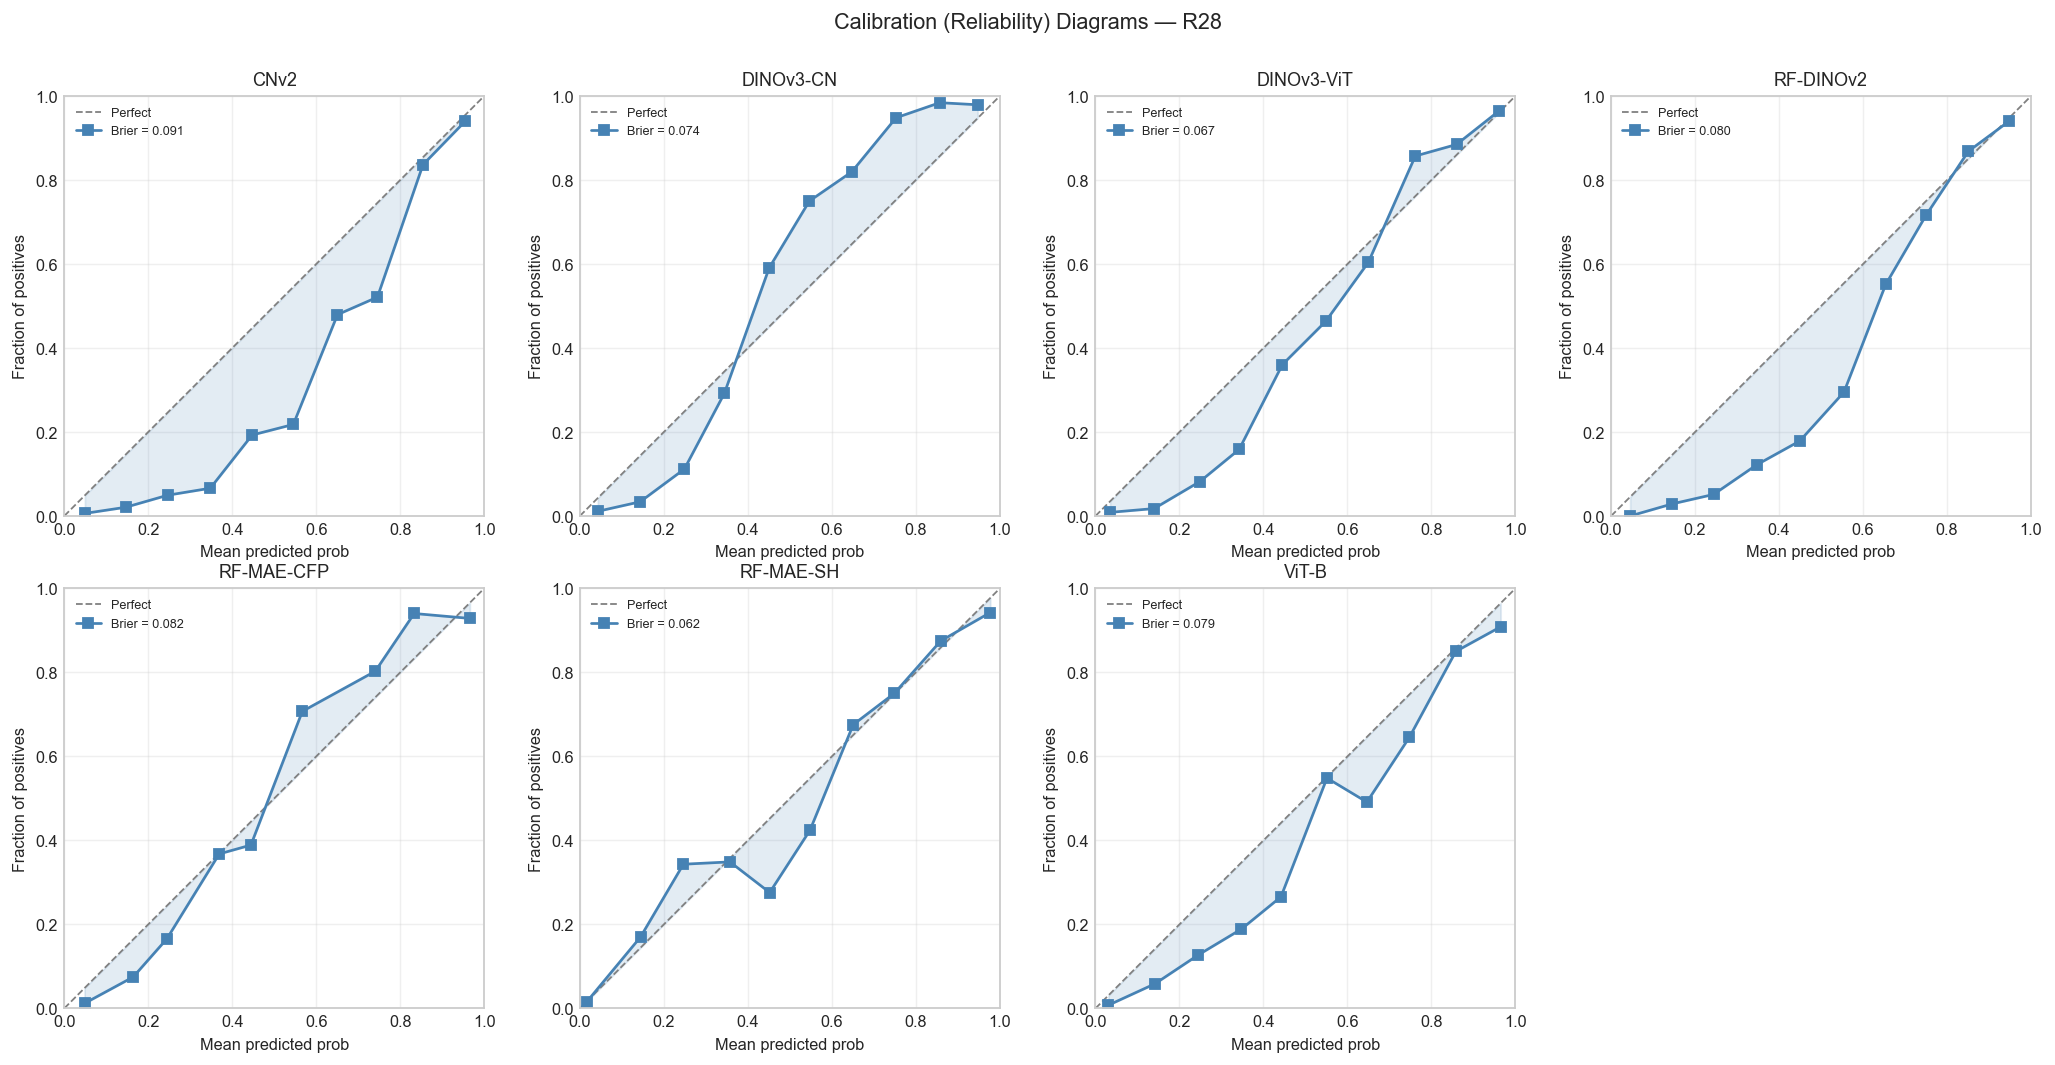

  CNv2          Brier = 0.0912
  DINOv3-CN     Brier = 0.0743
  DINOv3-ViT    Brier = 0.0672
  RF-DINOv2     Brier = 0.0801
  RF-MAE-CFP    Brier = 0.0824
  RF-MAE-SH     Brier = 0.0621
  ViT-B         Brier = 0.0792

  → Saved to validation_suite/test2_calibration.png

════════════════════════════════════════════════════════════════════════
  TEST 3 — Subgroup Fairness Analysis
════════════════════════════════════════════════════════════════════════
  Subgroup               n  prev       CNv2  DINOv3-CN DINOv3-ViT  RF-DINOv2 RF-MAE-CFP  RF-MAE-SH      ViT-B
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Age 40–59            338 0.24      0.855      0.871      0.850      0.874      0.789      0.838      0.864
  Age 60+             1191 0.24      0.804      0.810      0.814      0.816      0.775      0.818      0.750
  Age <40              176 0.22      0.757      0.853      0.773      0.783      0.727      0.794   

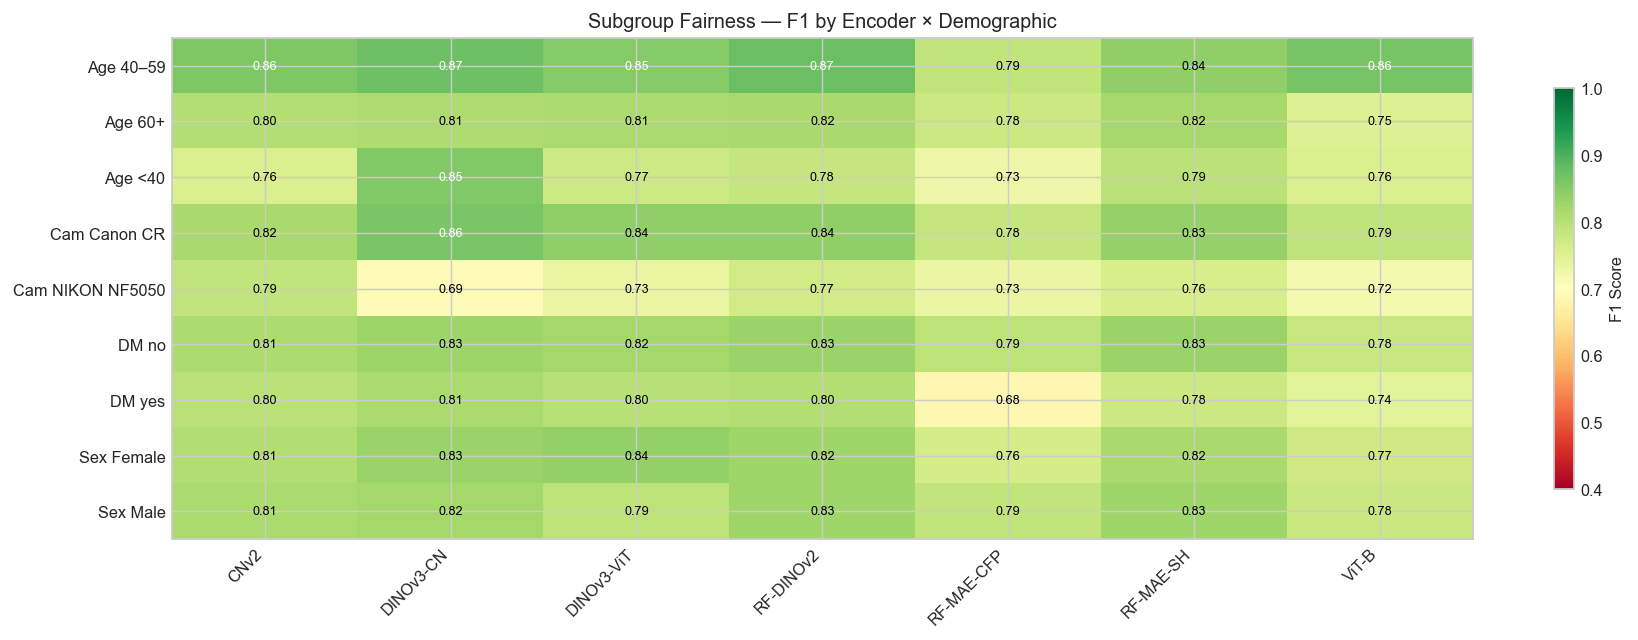


  → Saved to validation_suite/test3_subgroup_fairness.csv + .png

════════════════════════════════════════════════════════════════════════
  TEST 4 — Inter-Encoder Agreement (Pairwise Cohen's κ)
════════════════════════════════════════════════════════════════════════

                     CNv2  DINOv3-CN DINOv3-ViT  RF-DINOv2 RF-MAE-CFP  RF-MAE-SH      ViT-B
  CNv2              1.000      0.736      0.725      0.740      0.679      0.711      0.701
  DINOv3-CN         0.736      1.000      0.785      0.734      0.633      0.702      0.673
  DINOv3-ViT        0.725      0.785      1.000      0.690      0.663      0.704      0.672
  RF-DINOv2         0.740      0.734      0.690      1.000      0.676      0.742      0.685
  RF-MAE-CFP        0.679      0.633      0.663      0.676      1.000      0.715      0.649
  RF-MAE-SH         0.711      0.702      0.704      0.742      0.715      1.000      0.696
  ViT-B             0.701      0.673      0.672      0.685      0.649      0.696      

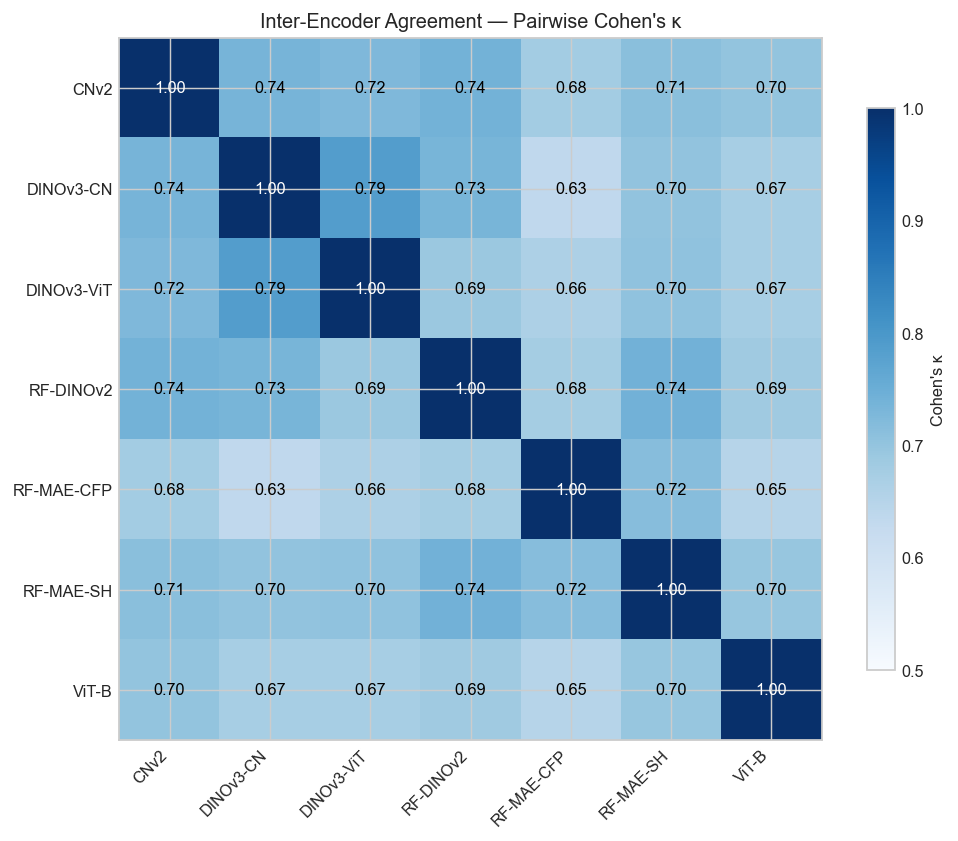


  → Saved to validation_suite/test4_inter_encoder_kappa.csv + .png

════════════════════════════════════════════════════════════════════════
  TEST 5 — Prediction Error Analysis
════════════════════════════════════════════════════════════════════════

  Agreement distribution (how many encoders got it right):
    0/7 correct:   11 patients (  0.6%)  █
    1/7 correct:   17 patients (  1.0%)  █
    2/7 correct:   31 patients (  1.8%)  █
    3/7 correct:   44 patients (  2.6%)  ██
    4/7 correct:   63 patients (  3.7%)  ███
    5/7 correct:  104 patients (  6.1%)  █████
    6/7 correct:  199 patients ( 11.7%)  █████████
    7/7 correct: 1236 patients ( 72.5%)  █████████████████████████████████████████████████████████████

  Unanimous correct (7/7): 1236/1705 (72.5%)

  Patients misclassified by ≥ 5/7 encoders: 59
    Hard False Negatives (glaucoma+ missed): 32
    Hard False Positives (healthy flagged) : 27

  Demographics — hard cases (n=59) vs entire test (n=1705):
    Mean age:  65.

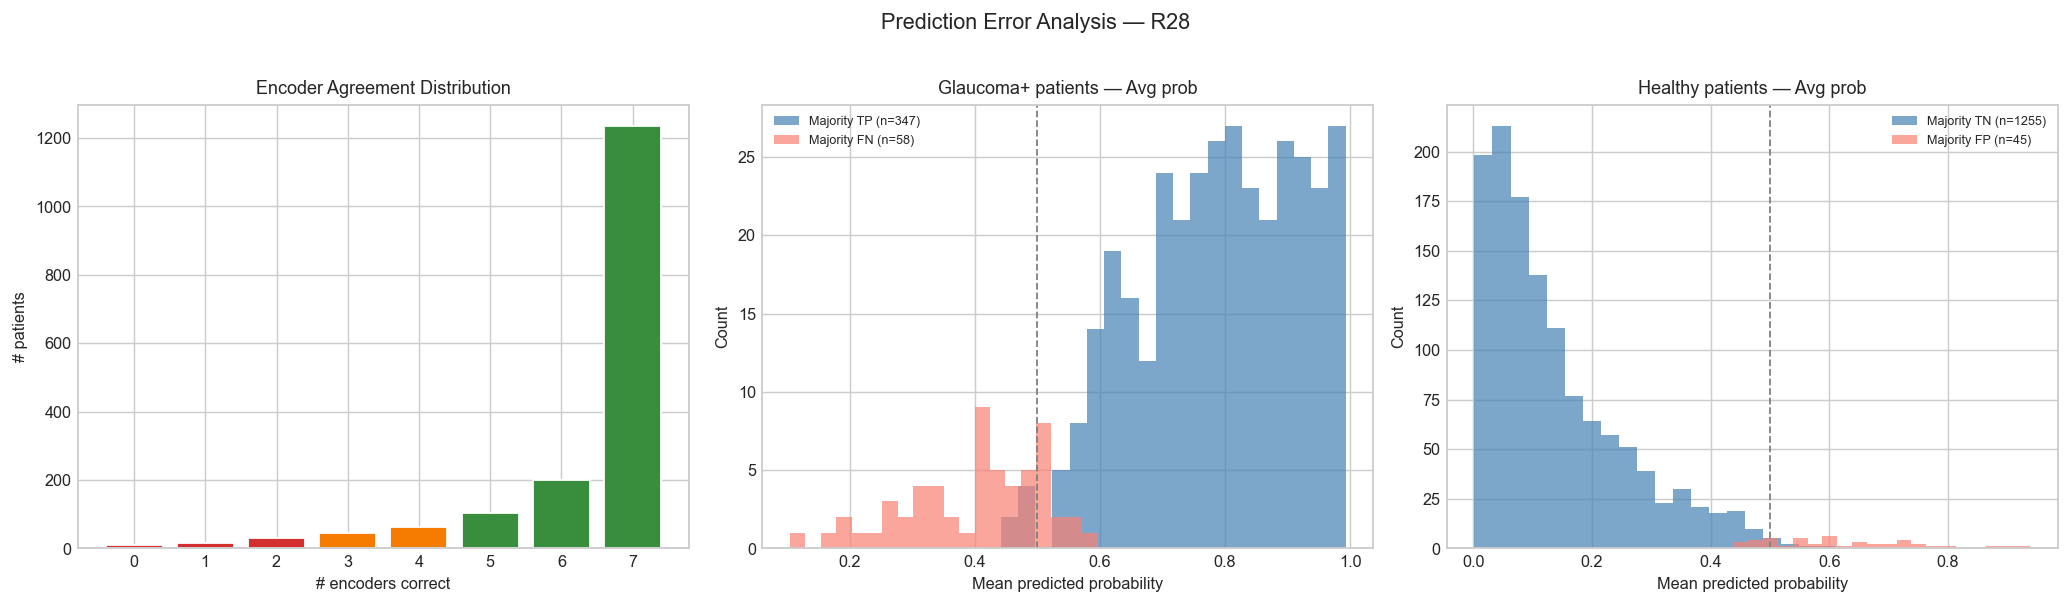


  → Saved to validation_suite/test5_error_analysis.png + test5_hard_cases.csv


════════════════════════════════════════════════════════════════════════
  VALIDATION SUITE SUMMARY
════════════════════════════════════════════════════════════════════════
  ✅ Bootstrap CI width (F1)              0.059  [PASS]
  ✅ Mean Brier score                    0.0766  [PASS]
  ⚠️ Max fairness gap                     0.169  [WATCH]
  ✅ Mean inter-encoder κ                 0.701  [PASS]
  ⚠️ Unanimous agreement                  72.5%  [WATCH]
  ⚠️ Hard false negatives                    32  [WATCH]

  All artefacts saved to: C:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r28_fe_experiment\validation_suite
  ✓ Validation suite complete.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# § 13  Validation Suite — R28 Per-Encoder Model Testing
# ═══════════════════════════════════════════════════════════════════════
# Self-contained: no dependency on prior cell execution.
# ───────────────────────────────────────────────────────────────────────

import pathlib, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, roc_auc_score, brier_score_loss,
    cohen_kappa_score, precision_score, recall_score,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 130, "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
})

# ── Paths ────────────────────────────────────────────────────────────
BASE_DIR    = pathlib.Path(
    r"C:\Users\Julian\OneDrive\Desktop\testing-retina-project"
    r"\Retina-Project-Evaluation\main-project"
)
R28_DIR     = BASE_DIR / "results" / "brset_r28_fe_experiment" / "r28_per_encoder"
LABELS_PATH = BASE_DIR / "data" / "brset_embeddings" / "brset_labels" / "labels_brset.csv"
SAVE_DIR    = R28_DIR.parent / "validation_suite"
SAVE_DIR.mkdir(exist_ok=True)

SEED   = 42
N_BOOT = 1_000

# ── Load all encoder predictions ─────────────────────────────────────
encoder_dirs = sorted([d for d in R28_DIR.iterdir() if d.is_dir()])
preds: dict[str, pd.DataFrame] = {}
for d in encoder_dirs:
    pf = d / "patient_predictions_P25.csv"
    if pf.exists():
        name = d.name[3:]          # strip "00_" index prefix
        preds[name] = pd.read_csv(pf)

enc_names = list(preds.keys())
SHORT = {
    "convnextv2_base_":            "CNv2",
    "dinov3_convnext_base":        "DINOv3-CN",
    "dinov3_vitb16":               "DINOv3-ViT",
    "RETFound_dinov2_shanghai":    "RF-DINOv2",
    "RETFound_mae_natureCFP":      "RF-MAE-CFP",
    "RETFound_mae_shanghai":       "RF-MAE-SH",
    "vit_base_":                   "ViT-B",
}
for e in enc_names:            # fallback for unexpected names
    SHORT.setdefault(e, e[:12])

print(f"✓ Loaded {len(enc_names)} encoders, "
      f"{len(preds[enc_names[0]])} test patients each\n")

# ── Load demographics (patient-level) ────────────────────────────────
labels_raw = pd.read_csv(LABELS_PATH)
demo = (
    labels_raw.groupby("patient_id").first().reset_index()
    [["patient_id", "patient_age", "patient_sex", "diabetes", "camera"]]
)

sex_map = {1: "Male", 2: "Female"}

def age_bin(a):
    if a < 40:  return "<40"
    if a < 60:  return "40–59"
    return "60+"


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  TEST 1 — Bootstrap 95 % Confidence Intervals                    ║
# ╚═══════════════════════════════════════════════════════════════════╝
rng = np.random.default_rng(SEED)
boot = {}

for enc in enc_names:
    df = preds[enc]
    yt  = df["y_true"].values
    yp  = df["y_pred"].values
    ypr = df["y_proba"].values
    n   = len(yt)

    f1s, aucs, precs, recs = [], [], [], []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        yt_b, yp_b, ypr_b = yt[idx], yp[idx], ypr[idx]
        if len(np.unique(yt_b)) < 2:
            continue
        f1s.append(f1_score(yt_b, yp_b))
        aucs.append(roc_auc_score(yt_b, ypr_b))
        precs.append(precision_score(yt_b, yp_b, zero_division=0))
        recs.append(recall_score(yt_b, yp_b))

    boot[enc] = {
        "F1_mean": np.mean(f1s),   "F1_lo": np.percentile(f1s, 2.5),   "F1_hi": np.percentile(f1s, 97.5),
        "AUC_mean": np.mean(aucs), "AUC_lo": np.percentile(aucs, 2.5), "AUC_hi": np.percentile(aucs, 97.5),
        "Prec_mean": np.mean(precs), "Prec_lo": np.percentile(precs, 2.5), "Prec_hi": np.percentile(precs, 97.5),
        "Rec_mean": np.mean(recs),  "Rec_lo": np.percentile(recs, 2.5),  "Rec_hi": np.percentile(recs, 97.5),
    }

print("═" * 72)
print("  TEST 1 — Bootstrap 95 % Confidence Intervals  (n = 1,000 resamples)")
print("═" * 72)
for enc in enc_names:
    r = boot[enc]
    print(f"  {SHORT[enc]:12s}  "
          f"F1 {r['F1_mean']:.3f} [{r['F1_lo']:.3f}–{r['F1_hi']:.3f}]   "
          f"AUC {r['AUC_mean']:.3f} [{r['AUC_lo']:.3f}–{r['AUC_hi']:.3f}]   "
          f"Prec {r['Prec_mean']:.3f} [{r['Prec_lo']:.3f}–{r['Prec_hi']:.3f}]   "
          f"Rec {r['Rec_mean']:.3f} [{r['Rec_lo']:.3f}–{r['Rec_hi']:.3f}]")

# ── Forest plot (F1 + AUC) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["F1", "AUC"]):
    y_pos  = range(len(enc_names))
    means  = [boot[e][f"{metric}_mean"] for e in enc_names]
    los    = [boot[e][f"{metric}_lo"]   for e in enc_names]
    his    = [boot[e][f"{metric}_hi"]   for e in enc_names]
    errs   = [[m - l for m, l in zip(means, los)],
              [h - m for m, h in zip(means, his)]]
    ax.errorbar(means, list(y_pos), xerr=errs, fmt="o", capsize=4,
                color="steelblue", markersize=6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([SHORT[e] for e in enc_names])
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} — 95 % Bootstrap CI")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(SAVE_DIR / "test1_bootstrap_ci.png", bbox_inches="tight")
plt.show()

# Save CI table
boot_df = pd.DataFrame(boot).T
boot_df.index.name = "encoder"
boot_df.to_csv(SAVE_DIR / "test1_bootstrap_ci.csv")
print(f"\n  → Saved to {SAVE_DIR.name}/test1_bootstrap_ci.csv + .png")


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  TEST 2 — Calibration (Reliability) Diagrams                     ║
# ╚═══════════════════════════════════════════════════════════════════╝
print("\n" + "═" * 72)
print("  TEST 2 — Calibration (Reliability) Diagrams")
print("═" * 72)

n_bins = 10
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

brier_scores = {}
for i, enc in enumerate(enc_names):
    ax = axes_flat[i]
    df = preds[enc]
    prob_true, prob_pred = calibration_curve(
        df["y_true"], df["y_proba"], n_bins=n_bins, strategy="uniform"
    )
    brier = brier_score_loss(df["y_true"], df["y_proba"])
    brier_scores[enc] = brier

    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect")
    ax.plot(prob_pred, prob_true, "s-", color="steelblue", lw=1.5,
            markersize=5, label=f"Brier = {brier:.3f}")
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color="steelblue")
    ax.set_xlabel("Mean predicted prob")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(SHORT[enc])
    ax.legend(fontsize=7, loc="upper left")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

# hide unused subplot
for j in range(len(enc_names), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Calibration (Reliability) Diagrams — R28", fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(SAVE_DIR / "test2_calibration.png", bbox_inches="tight")
plt.show()

for enc in enc_names:
    print(f"  {SHORT[enc]:12s}  Brier = {brier_scores[enc]:.4f}")

print(f"\n  → Saved to {SAVE_DIR.name}/test2_calibration.png")


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  TEST 3 — Subgroup Fairness Analysis                             ║
# ╚═══════════════════════════════════════════════════════════════════╝
print("\n" + "═" * 72)
print("  TEST 3 — Subgroup Fairness Analysis")
print("═" * 72)

MIN_N = 20                 # minimum subgroup size for reliable F1
subgroup_results = {}

for enc in enc_names:
    df = preds[enc].merge(demo, on="patient_id", how="left")
    df["age_group"]  = df["patient_age"].apply(age_bin)
    df["sex_label"]  = df["patient_sex"].map(sex_map)
    enc_sub = {}

    # -- Age groups --
    for grp in ["<40", "40–59", "60+"]:
        sub = df[df["age_group"] == grp]
        if len(sub) >= MIN_N and sub["y_true"].nunique() == 2:
            enc_sub[f"Age {grp}"] = {
                "f1": f1_score(sub["y_true"], sub["y_pred"]),
                "n": len(sub), "prev": sub["y_true"].mean(),
            }

    # -- Sex --
    for sex in ["Male", "Female"]:
        sub = df[df["sex_label"] == sex]
        if len(sub) >= MIN_N and sub["y_true"].nunique() == 2:
            enc_sub[f"Sex {sex}"] = {
                "f1": f1_score(sub["y_true"], sub["y_pred"]),
                "n": len(sub), "prev": sub["y_true"].mean(),
            }

    # -- Diabetes --
    for diab in ["yes", "no"]:
        sub = df[df["diabetes"] == diab]
        if len(sub) >= MIN_N and sub["y_true"].nunique() == 2:
            enc_sub[f"DM {diab}"] = {
                "f1": f1_score(sub["y_true"], sub["y_pred"]),
                "n": len(sub), "prev": sub["y_true"].mean(),
            }

    # -- Camera --
    for cam in sorted(df["camera"].dropna().unique()):
        sub = df[df["camera"] == cam]
        if len(sub) >= MIN_N and sub["y_true"].nunique() == 2:
            enc_sub[f"Cam {cam}"] = {
                "f1": f1_score(sub["y_true"], sub["y_pred"]),
                "n": len(sub), "prev": sub["y_true"].mean(),
            }

    subgroup_results[enc] = enc_sub

# -- Collect all subgroup keys --
sg_keys = sorted(
    set().union(*[sr.keys() for sr in subgroup_results.values()]),
    key=lambda k: (k.split()[0], k),          # group by category
)

# -- Print table --
header = f"  {'Subgroup':18s} {'n':>5s} {'prev':>5s}"
for enc in enc_names:
    header += f" {SHORT[enc]:>10s}"
print(header)
print("  " + "─" * (30 + 12 * len(enc_names)))

for sg in sg_keys:
    # get n and prev from first encoder that has it
    meta = next((subgroup_results[e][sg] for e in enc_names if sg in subgroup_results[e]), None)
    n_str   = f"{meta['n']:5d}" if meta else "    —"
    prev_str = f"{meta['prev']:.2f}" if meta else "   —"
    row = f"  {sg:18s} {n_str} {prev_str}"
    for enc in enc_names:
        if sg in subgroup_results[enc]:
            row += f" {subgroup_results[enc][sg]['f1']:10.3f}"
        else:
            row += f" {'—':>10s}"
    print(row)

# -- Fairness gaps --
print("\n  Max fairness gap (max − min F1 within demographic category):")
for enc in enc_names:
    sr   = subgroup_results[enc]
    gaps = {}
    for cat in ["Age", "Sex", "DM", "Cam"]:
        vals = [v["f1"] for k, v in sr.items() if k.startswith(cat)]
        if len(vals) >= 2:
            gaps[cat] = max(vals) - min(vals)
    gap_str = "  ".join(f"{k}={v:.3f}" for k, v in gaps.items())
    print(f"    {SHORT[enc]:12s}  {gap_str}")

# -- Heatmap --
fig, ax = plt.subplots(figsize=(14, 5))
data_mx = np.full((len(sg_keys), len(enc_names)), np.nan)
for i, sg in enumerate(sg_keys):
    for j, enc in enumerate(enc_names):
        if sg in subgroup_results[enc]:
            data_mx[i, j] = subgroup_results[enc][sg]["f1"]

im = ax.imshow(data_mx, cmap="RdYlGn", aspect="auto", vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(enc_names)))
ax.set_xticklabels([SHORT[e] for e in enc_names], rotation=45, ha="right")
ax.set_yticks(range(len(sg_keys)))
ax.set_yticklabels(sg_keys)
for i in range(len(sg_keys)):
    for j in range(len(enc_names)):
        v = data_mx[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="black" if 0.55 < v < 0.85 else "white")
plt.colorbar(im, ax=ax, label="F1 Score", shrink=0.8)
ax.set_title("Subgroup Fairness — F1 by Encoder × Demographic", fontsize=11)
fig.tight_layout()
fig.savefig(SAVE_DIR / "test3_subgroup_fairness.png", bbox_inches="tight")
plt.show()

# Save table
fair_rows = []
for sg in sg_keys:
    row = {"subgroup": sg}
    for enc in enc_names:
        if sg in subgroup_results[enc]:
            row[SHORT[enc]] = round(subgroup_results[enc][sg]["f1"], 4)
    fair_rows.append(row)
pd.DataFrame(fair_rows).to_csv(SAVE_DIR / "test3_subgroup_fairness.csv", index=False)
print(f"\n  → Saved to {SAVE_DIR.name}/test3_subgroup_fairness.csv + .png")


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  TEST 4 — Inter-Encoder Agreement (Pairwise Cohen's κ)           ║
# ╚═══════════════════════════════════════════════════════════════════╝
print("\n" + "═" * 72)
print("  TEST 4 — Inter-Encoder Agreement (Pairwise Cohen's κ)")
print("═" * 72)

n_enc = len(enc_names)
kappa_mx = np.ones((n_enc, n_enc))

for i in range(n_enc):
    for j in range(i + 1, n_enc):
        merged = preds[enc_names[i]][["patient_id", "y_pred"]].merge(
            preds[enc_names[j]][["patient_id", "y_pred"]],
            on="patient_id", suffixes=("_a", "_b"),
        )
        k = cohen_kappa_score(merged["y_pred_a"], merged["y_pred_b"])
        kappa_mx[i, j] = k
        kappa_mx[j, i] = k

# Print matrix
print(f"\n  {'':12s}", end="")
for e in enc_names:
    print(f" {SHORT[e]:>10s}", end="")
print()
for i, e1 in enumerate(enc_names):
    print(f"  {SHORT[e1]:12s}", end="")
    for j in range(n_enc):
        print(f" {kappa_mx[i,j]:10.3f}", end="")
    print()

off_diag = kappa_mx[np.triu_indices(n_enc, k=1)]
print(f"\n  Mean pairwise κ = {off_diag.mean():.3f}  "
      f"(min = {off_diag.min():.3f}, max = {off_diag.max():.3f})")

# Interpretation guide
mk = off_diag.mean()
if mk >= 0.81:   interp = "almost perfect"
elif mk >= 0.61: interp = "substantial"
elif mk >= 0.41: interp = "moderate"
else:            interp = "fair-to-poor"
print(f"  Landis & Koch interpretation: {interp} agreement")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(kappa_mx, cmap="Blues", vmin=0.5, vmax=1.0)
ax.set_xticks(range(n_enc))
ax.set_xticklabels([SHORT[e] for e in enc_names], rotation=45, ha="right")
ax.set_yticks(range(n_enc))
ax.set_yticklabels([SHORT[e] for e in enc_names])
for i in range(n_enc):
    for j in range(n_enc):
        ax.text(j, i, f"{kappa_mx[i,j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if kappa_mx[i,j] > 0.80 else "black")
plt.colorbar(im, ax=ax, label="Cohen's κ", shrink=0.8)
ax.set_title("Inter-Encoder Agreement — Pairwise Cohen's κ", fontsize=11)
fig.tight_layout()
fig.savefig(SAVE_DIR / "test4_inter_encoder_kappa.png", bbox_inches="tight")
plt.show()

# Save
pd.DataFrame(kappa_mx, index=[SHORT[e] for e in enc_names],
             columns=[SHORT[e] for e in enc_names]).to_csv(
    SAVE_DIR / "test4_inter_encoder_kappa.csv"
)
print(f"\n  → Saved to {SAVE_DIR.name}/test4_inter_encoder_kappa.csv + .png")


# ╔═══════════════════════════════════════════════════════════════════╗
# ║  TEST 5 — Prediction Error Analysis                               ║
# ╚═══════════════════════════════════════════════════════════════════╝
print("\n" + "═" * 72)
print("  TEST 5 — Prediction Error Analysis")
print("═" * 72)

# Build master table — one row per test patient
master = preds[enc_names[0]][["patient_id", "y_true"]].copy()
for enc in enc_names:
    tmp = preds[enc].set_index("patient_id")
    master[f"pred_{enc}"]  = master["patient_id"].map(tmp["y_pred"])
    master[f"prob_{enc}"]  = master["patient_id"].map(tmp["y_proba"])

pred_cols = [f"pred_{e}" for e in enc_names]
prob_cols = [f"prob_{e}" for e in enc_names]

master["n_correct"] = (
    master[pred_cols].values == master["y_true"].values[:, None]
).sum(axis=1)
master["n_wrong"]   = n_enc - master["n_correct"]
master["mean_prob"] = master[prob_cols].mean(axis=1)

# -- Agreement distribution --
agree = master["n_correct"].value_counts().sort_index()
print("\n  Agreement distribution (how many encoders got it right):")
total = len(master)
for nc, cnt in agree.items():
    bar = "█" * max(1, cnt // 20)
    print(f"    {nc}/{n_enc} correct: {cnt:4d} patients ({100*cnt/total:5.1f}%)  {bar}")

unanimous = master[master["n_correct"] == n_enc]
print(f"\n  Unanimous correct (7/7): {len(unanimous)}/{total} "
      f"({100*len(unanimous)/total:.1f}%)")

# -- Hard cases (wrong by ≥ 5 encoders) --
HARD_THRESH = 5
hard = master[master["n_wrong"] >= HARD_THRESH].sort_values("n_wrong", ascending=False)
hard_fn = hard[hard["y_true"] == 1]
hard_fp = hard[hard["y_true"] == 0]

print(f"\n  Patients misclassified by ≥ {HARD_THRESH}/{n_enc} encoders: {len(hard)}")
print(f"    Hard False Negatives (glaucoma+ missed): {len(hard_fn)}")
print(f"    Hard False Positives (healthy flagged) : {len(hard_fp)}")

# -- Demographics of hard cases vs overall test --
if len(hard) > 0:
    hd = hard.merge(demo, on="patient_id", how="left")
    td = master.merge(demo, on="patient_id", how="left")
    print(f"\n  Demographics — hard cases (n={len(hard)}) vs entire test (n={total}):")
    print(f"    Mean age:  {hd['patient_age'].mean():.1f}  vs  {td['patient_age'].mean():.1f}")
    hard_sex  = hd["patient_sex"].map(sex_map).value_counts(normalize=True)
    test_sex  = td["patient_sex"].map(sex_map).value_counts(normalize=True)
    print(f"    % Female:  {hard_sex.get('Female',0)*100:.1f}%  vs  {test_sex.get('Female',0)*100:.1f}%")
    hard_dm = hd["diabetes"].value_counts(normalize=True)
    test_dm = td["diabetes"].value_counts(normalize=True)
    print(f"    % DM yes:  {hard_dm.get('yes',0)*100:.1f}%  vs  {test_dm.get('yes',0)*100:.1f}%")
    if "camera" in hd.columns:
        hard_cam = hd["camera"].value_counts(normalize=True)
        print(f"    Camera dist (hard): {dict(hard_cam.apply(lambda x: f'{x:.2f}'))}")

# -- Plots --
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 5a. Agreement bar chart
agree_sorted = agree.sort_index()
colors = ["#d32f2f" if k <= 2 else "#f57c00" if k <= 4 else "#388e3c"
          for k in agree_sorted.index]
axes[0].bar(agree_sorted.index, agree_sorted.values, color=colors, edgecolor="white")
axes[0].set_xlabel("# encoders correct")
axes[0].set_ylabel("# patients")
axes[0].set_title("Encoder Agreement Distribution")
axes[0].set_xticks(range(0, n_enc + 1))

# 5b. Probability histogram — glaucoma+ (TP vs FN by majority vote)
pos = master[master["y_true"] == 1]
pos_correct = pos[pos[pred_cols].sum(axis=1) >= 4]
pos_wrong   = pos[pos[pred_cols].sum(axis=1) <  4]
axes[1].hist(pos_correct["mean_prob"], bins=20, alpha=0.7,
             color="steelblue", label=f"Majority TP (n={len(pos_correct)})")
axes[1].hist(pos_wrong["mean_prob"], bins=20, alpha=0.7,
             color="salmon",    label=f"Majority FN (n={len(pos_wrong)})")
axes[1].axvline(0.5, color="gray", ls="--", lw=1)
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Glaucoma+ patients — Avg prob")
axes[1].legend(fontsize=7)

# 5c. Probability histogram — healthy (TN vs FP by majority vote)
neg = master[master["y_true"] == 0]
neg_correct = neg[neg[pred_cols].sum(axis=1) <= 3]
neg_wrong   = neg[neg[pred_cols].sum(axis=1) >  3]
axes[2].hist(neg_correct["mean_prob"], bins=20, alpha=0.7,
             color="steelblue", label=f"Majority TN (n={len(neg_correct)})")
axes[2].hist(neg_wrong["mean_prob"], bins=20, alpha=0.7,
             color="salmon",    label=f"Majority FP (n={len(neg_wrong)})")
axes[2].axvline(0.5, color="gray", ls="--", lw=1)
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Count")
axes[2].set_title("Healthy patients — Avg prob")
axes[2].legend(fontsize=7)

fig.suptitle("Prediction Error Analysis — R28", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(SAVE_DIR / "test5_error_analysis.png", bbox_inches="tight")
plt.show()

# -- Save hard-case list --
hard_save = hard[["patient_id", "y_true", "n_wrong", "mean_prob"]].copy()
hard_save.to_csv(SAVE_DIR / "test5_hard_cases.csv", index=False)
print(f"\n  → Saved to {SAVE_DIR.name}/test5_error_analysis.png + test5_hard_cases.csv")


# ═══════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════
print("\n\n" + "═" * 72)
print("  VALIDATION SUITE SUMMARY")
print("═" * 72)

# Quick pass/watch/fail flags
ci_width_f1 = np.mean([boot[e]["F1_hi"] - boot[e]["F1_lo"] for e in enc_names])
mean_brier  = np.mean(list(brier_scores.values()))
max_gap     = 0.0
for enc in enc_names:
    sr = subgroup_results[enc]
    for cat in ["Age", "Sex", "DM", "Cam"]:
        vals = [v["f1"] for k, v in sr.items() if k.startswith(cat)]
        if len(vals) >= 2:
            max_gap = max(max_gap, max(vals) - min(vals))

mk = off_diag.mean()
pct_unanimous = 100 * len(unanimous) / total

checks = [
    ("Bootstrap CI width (F1)",   f"{ci_width_f1:.3f}",   "PASS" if ci_width_f1 < 0.08 else "WATCH"),
    ("Mean Brier score",          f"{mean_brier:.4f}",     "PASS" if mean_brier < 0.20 else "WATCH"),
    ("Max fairness gap",          f"{max_gap:.3f}",        "PASS" if max_gap < 0.15 else "WATCH"),
    ("Mean inter-encoder κ",      f"{mk:.3f}",            "PASS" if mk > 0.60 else "WATCH"),
    ("Unanimous agreement",       f"{pct_unanimous:.1f}%", "PASS" if pct_unanimous > 75 else "WATCH"),
    ("Hard false negatives",      f"{len(hard_fn)}",       "PASS" if len(hard_fn) < 30 else "WATCH"),
]

for name, val, status in checks:
    icon = "✅" if status == "PASS" else "⚠️"
    print(f"  {icon} {name:30s}  {val:>10s}  [{status}]")

print(f"\n  All artefacts saved to: {SAVE_DIR}")
print("  ✓ Validation suite complete.")